<a href="https://colab.research.google.com/github/okpast/python-data-analysis-projects/blob/main/ecommerce_sales_statistical_analysis%5Cecommerce_sales_statistical_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Підключення до BigQuery та формування датасету

In [ ]:
# Встановлення/оновлення бібліотеки для роботи з BigQuery
!pip install --upgrade -q google-cloud-bigquery
# Встановлення/оновлення бібліотеки для пост-хок тестів
!pip install --upgrade -q scikit-posthocs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 743.5 kB/s eta 0:00:00


In [ ]:
# Імпорт необхідних бібліотек
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Авторизація облікового запису Google для доступу до BigQuery
auth.authenticate_user()

# Створення клієнта BigQuery для проєкту Google Cloud
project_id = 'data-analytics-mate'
client = bigquery.Client(project=project_id)

In [ ]:
# Запис SQL-запиту у змінну
query = """
SELECT
    s.date AS session_date,
    s.ga_session_id AS session_id,

    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name AS device_model,
    sp.operating_system,
    CASE
        WHEN sp.language LIKE 'en%' THEN 'English'
        WHEN sp.language LIKE 'es%' THEN 'Spanish'
        WHEN sp.language LIKE 'zh%' THEN 'Chinese'
        WHEN sp.language LIKE 'de%' THEN 'German'
        WHEN sp.language LIKE 'fr%' THEN 'French'
        WHEN sp.language LIKE 'ko%' THEN 'Korean'
        ELSE sp.language
    END AS browser_language,
    sp.name AS traffic_source,
    sp.channel AS traffic_channel,

    a.id AS account_id,
    a.is_verified AS is_email_confirmed,
    a.is_unsubscribed,

    p.category AS product_category,
    p.name AS product_name,
    p.price AS product_price,
    p.short_description

FROM `data-analytics-mate.DA.session` s
JOIN `data-analytics-mate.DA.session_params` sp
    ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
    ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` a
    ON acs.account_id = a.id
LEFT JOIN `data-analytics-mate.DA.order` o
    ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
    ON o.item_id = p.item_id
"""

# Виконання запиту та завантаження результатів у DataFrame
# df = client.query(query).to_dataframe()

# Виконання запиту та завантаження результатів у DataFrame.
# BigQuery Storage API вимкнено через відсутність дозволу
# 'bigquery.readsessions.create' у поточному проєкті.
# Результати завантажуються через стандартний BigQuery API.
df = client.query(query).to_dataframe(create_bqstorage_client=False)

# Перевірка розмірності отриманих даних
print("Розмірність датасету:", df.shape)

# Вивід перших 5 рядків
df.head()

Розмірність датасету: (349545, 18)


,session_date,session_id,continent,country,device,browser,device_model,operating_system,browser_language,traffic_source,traffic_channel,account_id,is_email_confirmed,is_unsubscribed,product_category,product_name,product_price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,Chinese,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,English,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,Chinese,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,Spanish,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,English,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


## 2. Дослідницький аналіз даних (EDA)

### 2.1 Первинний огляд структури

In [ ]:
# Структура та типи даних датасету після вивантаження з BigQuery
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   session_date        349545 non-null  dbdate 
 1   session_id          349545 non-null  Int64  
 2   continent           349545 non-null  object 
 3   country             349545 non-null  object 
 4   device              349545 non-null  object 
 5   browser             349545 non-null  object 
 6   device_model        349545 non-null  object 
 7   operating_system    349545 non-null  object 
 8   browser_language    235279 non-null  object 
 9   traffic_source      349545 non-null  object 
 10  traffic_channel     349545 non-null  object 
 11  account_id          27945 non-null   Int64  
 12  is_email_confirmed  27945 non-null   Int64  
 13  is_unsubscribed     27945 non-null   Int64  
 14  product_category    33538 non-null   object 
 15  product_name        33538 non-null

> **Висновок:** за результатами вивантаження даних з BigQuery отримано датасет обсягом **349 545 рядків** та **18 колонок**. Конектор BigQuery автоматично визначив частину типів даних: `session_id` та `account_id` мають тип `Int64` (nullable integer, що підтримує пропуски), а `session_date` представлено як тип `dbdate`, який відповідає типу `DATE` у BigQuery.
>
> Водночас 12 категоріальних колонок (`continent`, `country`, `device`, `browser` тощо) мають тип `object` і потребують конвертації до типу `category` для оптимізації використання пам'яті. Крім того, колонки `is_email_confirmed` та `is_unsubscribed` наразі мають тип `Int64` (значення `0/1`), хоча логічніше використовувати тип `boolean`.
>
> Первинний огляд також показав наявність пропусків у колонках `browser_language`, `account_id`, `is_email_confirmed` та `is_unsubscribed`. Крім того, чотири колонки, пов'язані з товарами (`product_category`, `product_name`, `product_price`, `short_description`), заповнені лише для **33 538** із **349 545** записів. Причини виникнення цих пропусків будуть проаналізовані в наступних підрозділах.

### 2.2 Зміна типів даних

In [ ]:
df["session_date"] = pd.to_datetime(df["session_date"])

category_cols = [
    "continent", "country", "device", "browser",
    "device_model", "operating_system",
    "browser_language", "traffic_source",
    "traffic_channel", "product_category"
]
df[category_cols] = df[category_cols].astype("category")

df["is_email_confirmed"] = df["is_email_confirmed"].astype("boolean")
df["is_unsubscribed"] = df["is_unsubscribed"].astype("boolean")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   session_date        349545 non-null  datetime64[ns]
 1   session_id          349545 non-null  Int64         
 2   continent           349545 non-null  category      
 3   country             349545 non-null  category      
 4   device              349545 non-null  category      
 5   browser             349545 non-null  category      
 6   device_model        349545 non-null  category      
 7   operating_system    349545 non-null  category      
 8   browser_language    235279 non-null  category      
 9   traffic_source      349545 non-null  category      
 10  traffic_channel     349545 non-null  category      
 11  account_id          27945 non-null   Int64         
 12  is_email_confirmed  27945 non-null   boolean       
 13  is_unsubscribed     27945 non

> **Висновок:** колонку `session_date` переведено з типу `object` у `datetime64[ns]` за допомогою `pd.to_datetime()`, що дозволяє коректно виконувати операції з датами — фільтрацію за періодом, групування за днями/тижнями/місяцями та обчислення часових інтервалів.
>
> 10 категоріальних колонок переведено з типу `object` у `category`, що дозволило зменшити використання пам'яті з 49.3 MB до приблизно 21.3 MB.
>
> Колонки `session_id` та `account_id` вже були представлені у форматі nullable `Int64`, що дозволяє коректно працювати з пропущеними значеннями (`NaN`). Це особливо важливо для `account_id`, оскільки він містить пропуски.
>
> Колонки `is_email_confirmed` та `is_unsubscribed` переведено з типу `Int64` (значення `0/1`) у nullable `boolean`, що краще відповідає їхній бінарній природі та дозволяє зберігати пропущені значення.

**Підсумкова структура типів даних після конвертації**

| Колонка | Опис | **Тип даних (Pandas)** |
| --- | --- | --- |
| **session_date** | Дата сесії користувача | `datetime64[ns]` |
| **session_id** | Унікальний ідентифікатор сесії | `Int64` (nullable, `<NA>`) |
| **continent** | Континент, з якого відбулась сесія | `category` |
| **country** | Країна, з якої відбулась сесія | `category` |
| **device** | Тип пристрою (desktop, mobile, tablet) | `category` |
| **browser** | Браузер користувача | `category` |
| **device_model** | Назва моделі пристрою | `category` |
| **operating_system** | Операційна система пристрою | `category` |
| **browser_language** | Мова браузера користувача | `category` |
| **traffic_source** | Джерело трафіку (direct, organic, referral...) | `category` |
| **traffic_channel** | Канал трафіку (Organic Search, Paid Search...) | `category` |
| **account_id** | Ідентифікатор зареєстрованого користувача | `Int64` (nullable, `<NA>`) |
| **is_email_confirmed** | Чи підтвердив користувач email | `boolean` (nullable, `<NA>`) |
| **is_unsubscribed** | Чи відписався користувач від розсилки | `boolean` (nullable, `<NA>`) |
| **product_category** | Категорія придбаного товару | `category` |
| **product_name** | Назва придбаного товару | `object` (текст) |
| **product_price** | Ціна товару | `float64` |
| **short_description** | Короткий опис товару | `object` (текст) |

### 2.3 Короткий опис датасету

In [ ]:
# Загальна кількість колонок
total_cols = df.shape[1]
print(f"Загальна кількість колонок: {total_cols}")

# Колонки числового типу
numeric_cols = df.select_dtypes(include=['int64', 'Int64', 'float64']).columns.tolist()
print(f"\nКількість колонок числового типу: {len(numeric_cols)}")
print(f"Колонки: {numeric_cols}")

# Колонки категоріального типу
categorical_cols = df.select_dtypes(include=['category']).columns.tolist()
print(f"\nКількість колонок категоріального типу: {len(categorical_cols)}")
print(f"Колонки: {categorical_cols}")

# Текстові колонки (object)
text_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nКількість текстових колонок: {len(text_cols)}")
print(f"Колонки: {text_cols}")

# Колонки типу boolean
boolean_cols = df.select_dtypes(include=['boolean', 'bool']).columns.tolist()
print(f"\nКількість колонок типу boolean: {len(boolean_cols)}")
print(f"Колонки: {boolean_cols}")

# Колонки типу datetime
datetime_cols = df.select_dtypes(include=['datetime64', 'datetime64[ns]']).columns.tolist()
print(f"\nКількість колонок типу datetime: {len(datetime_cols)}")
print(f"Колонки: {datetime_cols}")

# Кількість унікальних сесій
unique_sessions = df['session_id'].nunique()
print(f"\nКількість унікальних сесій: {unique_sessions}")

# Період часу
date_min = df['session_date'].min()
date_max = df['session_date'].max()
days_count = (date_max - date_min).days + 1

def days_word(n):
  if 11 <= n % 100 <= 14:
    return "днів"

  last_digit = n % 10
  if last_digit == 1:
    return "день"
  elif 2 <= last_digit <= 4:
    return "дні"
  else:
    return "днів"

print(f"\nПеріод часу: від {date_min.date()} до {date_max.date()} ({days_count} {days_word(days_count)})")

Загальна кількість колонок: 18

Кількість колонок числового типу: 3
Колонки: ['session_id', 'account_id', 'product_price']

Кількість колонок категоріального типу: 10
Колонки: ['continent', 'country', 'device', 'browser', 'device_model', 'operating_system', 'browser_language', 'traffic_source', 'traffic_channel', 'product_category']

Кількість текстових колонок: 2
Колонки: ['product_name', 'short_description']

Кількість колонок типу boolean: 2
Колонки: ['is_email_confirmed', 'is_unsubscribed']

Кількість колонок типу datetime: 1
Колонки: ['session_date']

Кількість унікальних сесій: 349545

Період часу: від 2020-11-01 до 2021-01-31 (92 дні)







> **Висновок:** датасет складається з **18 колонок**, які можна розподілити за типами:
>
> 1. **Числові колонки (3):**
>    - `session_id` — унікальний ідентифікатор сесії (`Int64`)
>    - `account_id` — ідентифікатор зареєстрованого користувача (`Int64`, nullable)
>    - `product_price` — ціна товару (`float64`)
>
> 2. **Категоріальні колонки (10):**
>    - `continent`, `country` — географія сесії
>    - `device`, `browser`, `device_model`, `operating_system`, `browser_language` — технічні параметри пристрою
>    - `traffic_source`, `traffic_channel` — джерело трафіку
>    - `product_category` — категорія товару
>
> 3. **Текстові колонки (2):**
>    - `product_name` — назва товару (`object`)
>    - `short_description` — короткий опис товару (`object`)
>
> 4. **Boolean-колонки (2):**
>    - `is_email_confirmed` — чи підтвердив користувач email (`boolean`, nullable)
>    - `is_unsubscribed` — чи відписався користувач від розсилки (`boolean`, nullable)
>
> 5. **Datetime-колонка (1):**
>    - `session_date` — дата проведення сесії (`datetime64[ns]`)
>
> Перевірка унікальності `session_id` показала відсутність дублікатів у завантаженому датасеті. Період спостереження охоплює **92 дні**: з **1 листопада 2020 року по 31 січня 2021 року**, що включає сезон високої активності e-commerce — Black Friday, різдвяні та новорічні покупки.



### 2.4 Аналіз пропущених значень

In [ ]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
})
missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)


,missing_count,missing_pct
account_id,321600,92.01
is_email_confirmed,321600,92.01
is_unsubscribed,321600,92.01
product_category,316007,90.41
product_price,316007,90.41
product_name,316007,90.41
short_description,316007,90.41
browser_language,114266,32.69


> **Висновок:** пропуски мають логічну природу, а не є дефектами даних:
> - **`account_id`, `is_email_confirmed`, `is_unsubscribed` (92.01%)** — оскільки датасет містить дані по **всіх** сесіях (включно з незареєстрованими користувачами), значення в цих колонках відсутні для сесій, де користувач не зареєструвався. Лише **8%** усіх сесій належать зареєстрованим користувачам.
> - **`product_category`, `product_name`, `product_price`, `short_description` (90.41%)** — дані відсутні для сесій, під час яких користувач не оформив замовлення.
> - **`browser_language` (32.69%)** — пропуски можуть бути спричинені налаштуваннями приватності користувача, застарілою версією браузера або технічними збоями під час збору даних. Частка пропусків приблизно однакова для всіх браузерів (~30–34%), що підтверджує: причина не пов'язана з конкретним браузером, а має системний характер.



### 2.5 Аналіз дублікатів

In [ ]:
# Перевірка датасету на наявність повних дублікатів рядків
duplicates_count = df.duplicated().sum()
print(f"Кількість дублікатів рядків: {duplicates_count}")

# Додаткова перевірка: чи є дублікати за session_id (мають бути унікальними)
session_id_duplicates = df['session_id'].duplicated().sum()
print(f"Кількість дублікатів session_id: {session_id_duplicates}")

Кількість дублікатів рядків: 0
Кількість дублікатів session_id: 0


> **Висновок:** повних дублікатів рядків у датасеті не виявлено. Додаткова перевірка за `session_id` (унікальним ідентифікатором сесії) також підтверджує відсутність повторів — кожна сесія представлена в датасеті рівно один раз. Це означає, що дані пройшли коректну дедублікацію ще на етапі формування SQL-запиту (JOIN-и не спричинили розмноження рядків), і подальший аналіз можна проводити без додаткової очистки від дублікатів.

### 2.6 Унікальні значення категоріальних колонок

In [ ]:
for col in ['continent', 'device', 'browser', 'operating_system', 'traffic_source', 'traffic_channel', 'product_category']:
  print(f"{col}: {df[col].nunique()} унікальних значень -> {sorted(df[col].dropna().unique())}")

print(f"country: {df['country'].nunique()} унікальних країн")

continent: 6 унікальних значень -> ['(not set)', 'Africa', 'Americas', 'Asia', 'Europe', 'Oceania']
device: 3 унікальних значень -> ['desktop', 'mobile', 'tablet']
browser: 6 унікальних значень -> ['<Other>', 'Android Webview', 'Chrome', 'Edge', 'Firefox', 'Safari']
operating_system: 6 унікальних значень -> ['<Other>', 'Android', 'Macintosh', 'Web', 'Windows', 'iOS']
traffic_source: 5 унікальних значень -> ['(data deleted)', '(direct)', '(organic)', '(referral)', '<Other>']
traffic_channel: 5 унікальних значень -> ['Direct', 'Organic Search', 'Paid Search', 'Social Search', 'Undefined']
product_category: 14 унікальних значень -> ['Bar furniture', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards', 'Café furniture', 'Chairs', 'Chests of drawers & drawer units', "Children's furniture", 'Nursery furniture', 'Outdoor furniture', 'Room dividers', 'Sideboards, buffets & console tables', 'Sofas & armchairs', 'Tables & desks']
country: 108 унікальних країн


> **Висновок:** у полях `continent`, `traffic_source`, `traffic_channel` є службові текстові мітки на кшталт `(not set)`, `Undefined`, `<Other>` — це **не NaN-пропуски**, а явні значення "невідомо/інше". Важливо не плутати їх з реальними пропусками у подальшому аналізі.

### 2.7 Зв'язок між реєстрацією та покупками

In [ ]:
df['has_account'] = df['account_id'].notna()
df['has_purchase'] = df['product_category'].notna()

pd.crosstab(df['has_account'], df['has_purchase'], normalize='index').round(3) * 100

has_purchase,False,True
has_account,,
False,90.4,9.6
True,90.0,10.0


> **Висновок:** частка сесій із покупкою практично однакова серед зареєстрованих (**10.0%**) і незареєстрованих користувачів (**9.6%**). Різниця становить **0.4 відсоткового пункту**, тому на етапі EDA немає підстав стверджувати про суттєвий зв'язок між наявністю акаунта та здійсненням покупки. Для підтвердження або спростування цієї гіпотези буде виконано тест хі-квадрат на незалежність у подальшому аналізі.

## 3. Аналіз продажів

### 3.1 Продажі за континентами та країнами

In [ ]:
# Фільтрація записів із здійсненими замовленнями (де вказано ціну товару)
df_orders = df[df['product_price'].notnull()].copy()


# Агрегація за континентами
continent_sales = df_orders.groupby('continent', observed=True)['product_price'].agg(
    total_sales='sum',
    order_count='count'
).reset_index()

top3_cont_sales = continent_sales.sort_values(by='total_sales', ascending=False).head(3)
top3_cont_orders = continent_sales.sort_values(by='order_count', ascending=False).head(3)

# Агрегація за країнами
country_sales = df_orders.groupby('country', observed=True)['product_price'].agg(
    total_sales='sum',
    order_count='count'
).reset_index()

top5_country_sales = country_sales.sort_values(by='total_sales', ascending=False).head(5)
top5_country_orders = country_sales.sort_values(by='order_count', ascending=False).head(5)

print("Топ-3 континенти за сумою продажів:")
for _, row in top3_cont_sales.iterrows():
  print(f"{row['continent']:<10} {'$' + format(row['total_sales'], ',.2f'):>15}")

print("\nТоп-3 континенти за кількістю замовлень:")
for _, row in top3_cont_orders.iterrows():
  print(f"{row['continent']:<10} {row['order_count']:>8,} замовлень")

print("\nТоп-5 країн за сумою продажів:")
for _, row in top5_country_sales.iterrows():
  print(f"{row['country']:<20} {'$' + format(row['total_sales'], ',.2f'):>15}")

print("\nТоп-5 країн за кількістю замовлень:")
for _, row in top5_country_orders.iterrows():
  print(f"{row['country']:<20} {row['order_count']:>8,} замовлень")

Топ-3 континенти за сумою продажів:
Americas    $17,665,280.00
Asia         $7,601,298.30
Europe       $5,934,624.20

Топ-3 континенти за кількістю замовлень:
Americas     18,553 замовлень
Asia          7,950 замовлень
Europe        6,261 замовлень

Топ-5 країн за сумою продажів:
United States         $13,943,553.90
India                  $2,809,762.00
Canada                 $2,437,921.00
United Kingdom           $938,317.90
France                   $710,692.80

Топ-5 країн за кількістю замовлень:
United States          14,673 замовлень
India                   3,029 замовлень
Canada                  2,560 замовлень
United Kingdom          1,029 замовлень
France                    678 замовлень


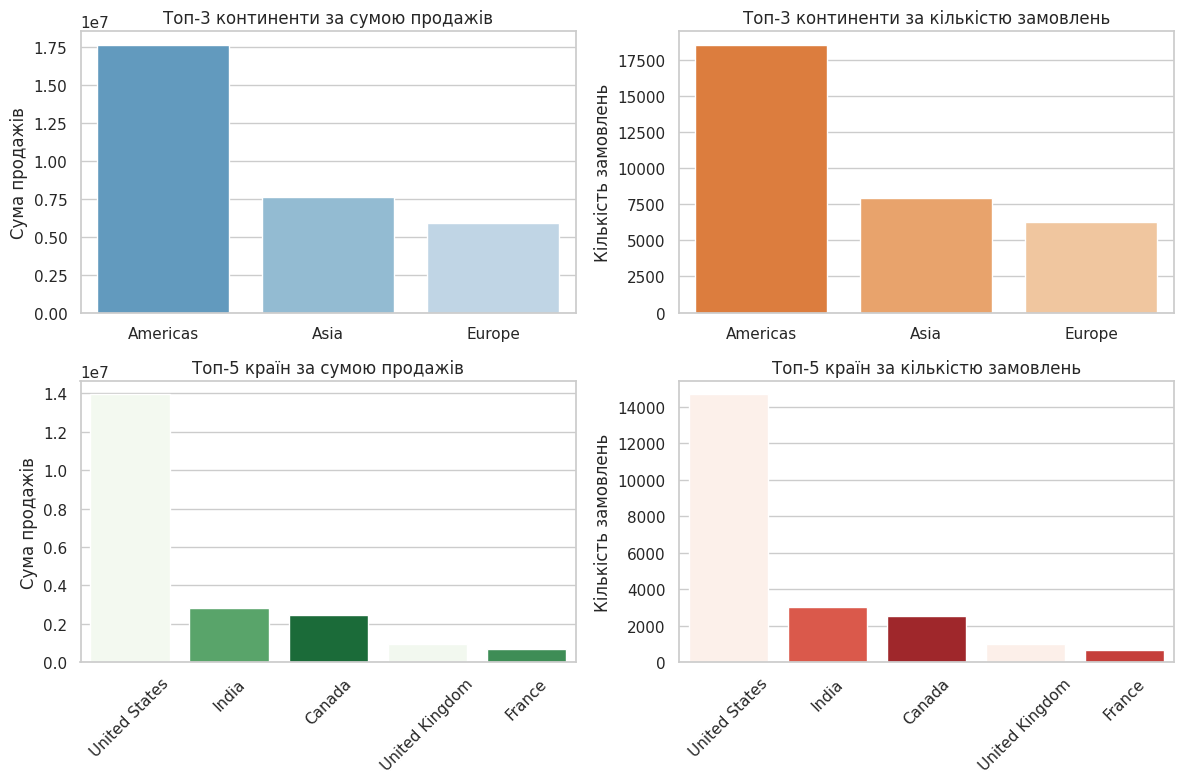

In [ ]:
# Налаштування стилю візуалізацій
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(data=top3_cont_sales, x='continent', y='total_sales', ax=axes[0,0],
            hue='continent', order=top3_cont_sales["continent"], dodge=False,
            palette='Blues_r', legend=False)

axes[0,0].set_title('Топ-3 континенти за сумою продажів')
axes[0,0].set_ylabel('Сума продажів')
axes[0,0].set_xlabel('')

sns.barplot(data=top3_cont_orders, x='continent', y='order_count', ax=axes[0,1],
            hue='continent', order=top3_cont_orders["continent"], dodge=False,
            palette='Oranges_r', legend=False)

axes[0,1].set_title('Топ-3 континенти за кількістю замовлень')
axes[0,1].set_ylabel('Кількість замовлень')
axes[0,1].set_xlabel('')


sns.barplot(data=top5_country_sales, x='country', y='total_sales', ax=axes[1,0],
            hue='country', order=top5_country_sales["country"], dodge=False,
            palette='Greens_r', legend=False)

axes[1,0].set_title('Топ-5 країн за сумою продажів')
axes[1,0].set_ylabel('Сума продажів')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=45)

sns.barplot(data=top5_country_orders, x='country', y='order_count', ax=axes[1,1],
            hue='country', order=top5_country_orders["country"], dodge=False,
            palette='Reds_r', legend=False)

axes[1,1].set_title('Топ-5 країн за кількістю замовлень')
axes[1,1].set_ylabel('Кількість замовлень')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> **Висновок:** беззаперечний лідер за обома метриками — континент **Americas** (17.67 млн продажів, 18 553 замовлення), що вдвічі перевищує **Asia** (7.6 млн, 7 950 замовлень); рейтинг Топ-3 континентів однаковий і за сумою, і за кількістю замовлень (**Americas → Asia → Europe**), що вказує на приблизно однаковий середній чек між ними. Серед країн домінує **United States** (13.94 млн, 14 673 замовлення) — майже **40%** глобальних продажів компанії та **79%** продажів усього континенту Americas, суттєво випереджаючи **India** (2.81 млн) та решту Топ-5 (**Canada, UK, France**), рейтинг яких теж збігається за обома метриками.

### 3.2 Продажі за категоріями товарів

In [ ]:
# Топ-10 категорій
top10_category_sales = df_orders.groupby('product_category', observed=True)['product_price'] \
  .sum().sort_values(ascending=False).head(10).reset_index(name='total_sales')

print(f"Топ-10 категорій за загальною сумою продажів:")
for i, (_, row) in enumerate(top10_category_sales.iterrows(), 1):
  print(f"{i:2}. {row['product_category']:<35} {'$' + format(row['total_sales'], ',.2f'):>16}")

# Країна з найбільшими продажами
top_country = df_orders.groupby('country', observed=True)['product_price'].sum().idxmax()

# Топ-10 категорій у країні з найбільшими продажами
top_country_orders = df_orders[df_orders['country'] == top_country]
top10_top_country_category_sales = top_country_orders.groupby("product_category", observed=True)["product_price"] \
  .sum().sort_values(ascending=False).head(10).reset_index(name="total_sales")

print(f"\nТоп-10 категорій у {top_country}:")
for i, (_, row) in enumerate(top10_top_country_category_sales.iterrows(), 1):
    print(f"{i:2}. {row['product_category']:<35} {'$' + format(row['total_sales'], ',.2f'):>16}")

Топ-10 категорій за загальною сумою продажів:
 1. Sofas & armchairs                      $8,388,254.50
 2. Chairs                                 $6,147,748.80
 3. Beds                                   $4,919,725.00
 4. Bookcases & shelving units             $3,640,818.10
 5. Cabinets & cupboards                   $2,336,499.50
 6. Outdoor furniture                      $2,142,222.20
 7. Tables & desks                         $1,790,307.50
 8. Chests of drawers & drawer units         $906,562.50
 9. Bar furniture                            $735,503.00
10. Children's furniture                     $467,697.00

Топ-10 категорій у United States:
 1. Sofas & armchairs                      $3,707,144.50
 2. Chairs                                 $2,619,773.80
 3. Beds                                   $2,213,058.00
 4. Bookcases & shelving units             $1,567,606.90
 5. Cabinets & cupboards                     $994,545.50
 6. Outdoor furniture                        $929,245.20
 7. Tab

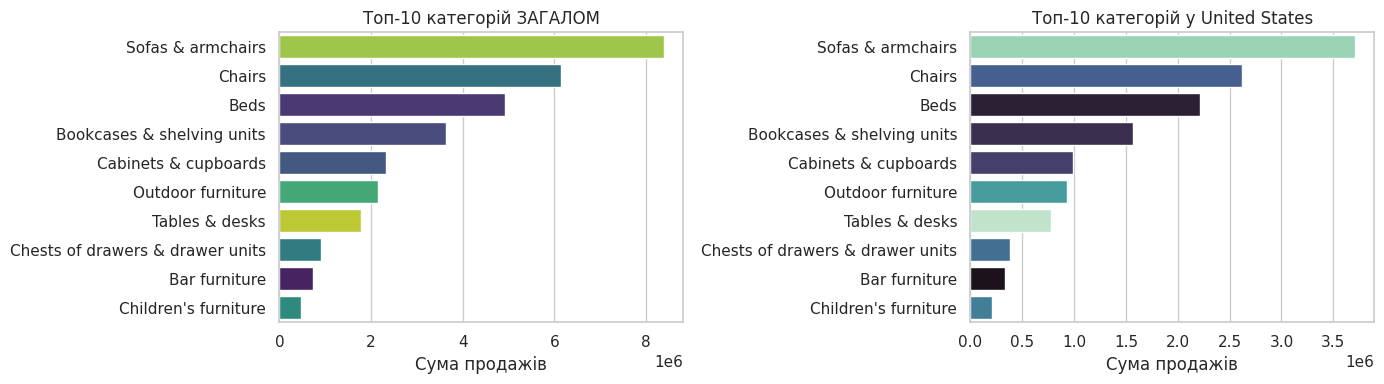

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=top10_category_sales, x='total_sales', y='product_category',
            hue='product_category', order=top10_category_sales["product_category"],
            dodge=False, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Топ-10 категорій ЗАГАЛОМ')
axes[0].set_xlabel('Сума продажів')
axes[0].set_ylabel('')

sns.barplot(data=top10_top_country_category_sales, x='total_sales', y='product_category',
            hue='product_category', order=top10_top_country_category_sales["product_category"],
            dodge=False, palette='mako', legend=False, ax=axes[1])
axes[1].set_title(f'Топ-10 категорій у {top_country}')
axes[1].set_xlabel('Сума продажів')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

> **Висновок:** рейтинг топ-10 категорій товарів **повністю ідентичний** і глобально, і в межах **United States** (лідери ті самі — **Sofas & armchairs → Chairs → Beds** тощо, без жодної перестановки), що логічно з огляду на те, що США формують **~44%** усіх глобальних продажів (13.94 млн з 31.97 млн) і фактично визначають загальну структуру попиту; це означає, що асортиментна стратегія, яка працює глобально, однаково добре підходить і під найбільший ринок компанії, тож окремої локалізації товарної матриці під США не потрібно.

### 3.3 Продажі за типами та моделями девайсів

In [ ]:
total_sales = df_orders['product_price'].sum()

# За типами девайсів
device_sales = df_orders.groupby('device', observed=True)['product_price'].sum().sort_values(ascending=False).reset_index(name='total_sales')
device_sales['pct'] = (device_sales['total_sales'] / total_sales * 100).round(2)

print("Продажі за типами девайсів (% від загальних):")
for _, row in device_sales.iterrows():
  print(f"{row['device'] + ':':<15} {'$' + format(row['total_sales'], ',.2f'):>16} ({row['pct']:>5}%)")

# За моделями девайсів
model_sales = df_orders.groupby('device_model', observed=True)['product_price'].sum().sort_values(ascending=False).reset_index(name='total_sales')
model_sales['pct'] = (model_sales['total_sales'] / total_sales * 100).round(2)

print(f"\nПродажі за моделями девайсів (% від загальних):")
for _, row in model_sales.iterrows():
    print(f"{row['device_model'] + ':':<15} {'$' + format(row['total_sales'], ',.2f'):>16} ({row['pct']:>5}%)")


Продажі за типами девайсів (% від загальних):
desktop:          $18,864,039.00 ( 59.0%)
mobile:           $12,384,225.80 (38.73%)
tablet:              $723,466.30 ( 2.26%)

Продажі за моделями девайсів (% від загальних):
Chrome:            $8,899,523.90 (27.84%)
<Other>:           $6,535,330.80 (20.44%)
Safari:            $6,491,062.10 ( 20.3%)
iPhone:            $6,420,776.30 (20.08%)
ChromeBook:        $1,830,458.70 ( 5.73%)
Edge:                $697,222.30 ( 2.18%)
iPad:                $448,854.20 (  1.4%)
Firefox:             $421,066.90 ( 1.32%)
Pixel 4 XL:          $118,287.70 ( 0.37%)
Pixel 3:             $109,148.20 ( 0.34%)


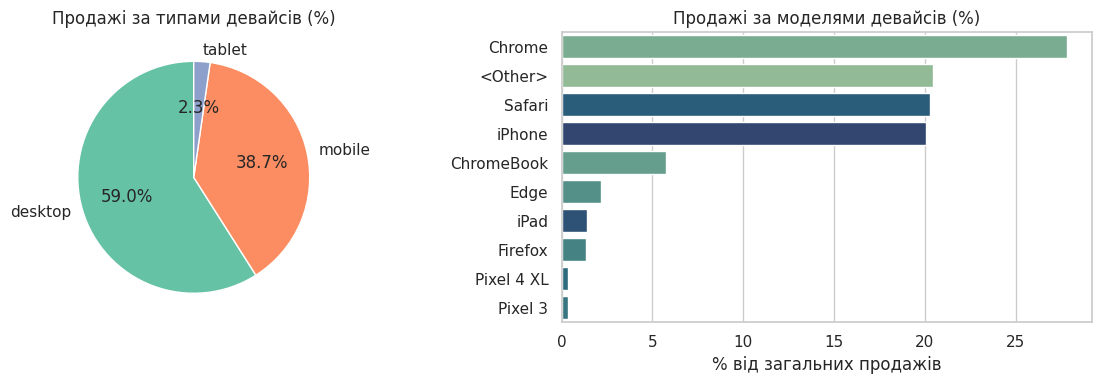

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Кругова діаграма через matplotlib.pyplot
axes[0].pie(device_sales['pct'], labels=device_sales['device'], autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[0].set_title('Продажі за типами девайсів (%)')

sns.barplot(data=model_sales, x='pct', y='device_model',
            hue='device_model', order=model_sales["device_model"],
            dodge=False, palette='crest', legend=False, ax=axes[1])
axes[1].set_title('Продажі за моделями девайсів (%)')
axes[1].set_xlabel('% від загальних продажів')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

> **Висновок:** **desktop** — беззаперечний лідер за продажами (**59.0%**), майже вдвічі перевищуючи **mobile** (**38.7%**), тоді як **tablet** формує лише **2.3%** і є другорядним каналом; важливий нюанс щодо колонки `device_model` — для desktop-пристроїв там записані назви браузерів (Chrome — 27.8%, Safari — 20.3%, ChromeBook — 5.7%, Edge — 2.2%, Firefox — 1.3%), а не фізичні моделі техніки, оскільки Google Analytics не відстежує "модель" для настільних комп'ютерів, тоді як для mobile/tablet там дійсно реальні моделі пристроїв: **iPhone** формує **20.1%** усіх продажів (найбільша окрема "модель" серед мобільних), а **Pixel 3/4 XL** — менше **1%** сумарно, що вказує на сильну перевагу Apple-екосистеми серед клієнтів, які купують з мобільних пристроїв.

### 3.4 Продажі за джерелами трафіку

In [ ]:
total_sales = df_orders['product_price'].sum()

# Продажі за каналом трафіку
channel_sales = df_orders.groupby('traffic_channel', observed=True)['product_price'].sum().sort_values(ascending=False).reset_index(name='total_sales')
channel_sales['pct'] = (channel_sales['total_sales'] / total_sales * 100).round(2)

# Конверсія за каналом трафіку: усі сесії vs сесії з покупкою
sessions_by_channel = df.groupby('traffic_channel', observed=True)['session_id'].nunique().reset_index(name='total_sessions')
orders_by_channel = df_orders.groupby('traffic_channel', observed=True)['session_id'].nunique().reset_index(name='orders_count')

conversion = sessions_by_channel.merge(orders_by_channel, on='traffic_channel', how='left')
conversion[['total_sessions', 'orders_count']] = conversion[['total_sessions', 'orders_count']].fillna(0)
conversion['conversion_rate'] = (conversion['orders_count'] / conversion['total_sessions'] * 100).round(2)
conversion = conversion.sort_values(by='conversion_rate', ascending=False)

print("Продажі за каналом трафіку (% від загальних):")
for _, row in channel_sales.iterrows():
  print(f"{row['traffic_channel'] + ':':<18} {'$' + format(row['total_sales'], ',.2f'):>16} ({row['pct']:>5}%)")

print("\nКонверсія за каналом трафіку (сесії → покупки):")
for _, row in conversion.iterrows():
  print(f"{row['traffic_channel'] + ':':<18} {int(row['total_sessions']):>8,} сесій -> {int(row['orders_count']):>6,} покупок ({row['conversion_rate']:>5}%)")

Продажі за каналом трафіку (% від загальних):
Organic Search:      $11,433,151.60 (35.76%)
Paid Search:          $8,511,049.40 (26.62%)
Direct:               $7,494,923.40 (23.44%)
Social Search:        $2,532,105.70 ( 7.92%)
Undefined:            $2,000,501.00 ( 6.26%)

Конверсія за каналом трафіку (сесії → покупки):
Social Search:       27,914 сесій ->  2,716 покупок ( 9.73%)
Direct:              81,382 сесій ->  7,800 покупок ( 9.58%)
Organic Search:     124,425 сесій -> 11,921 покупок ( 9.58%)
Paid Search:         94,341 сесій ->  9,042 покупок ( 9.58%)
Undefined:           21,483 сесій ->  2,059 покупок ( 9.58%)


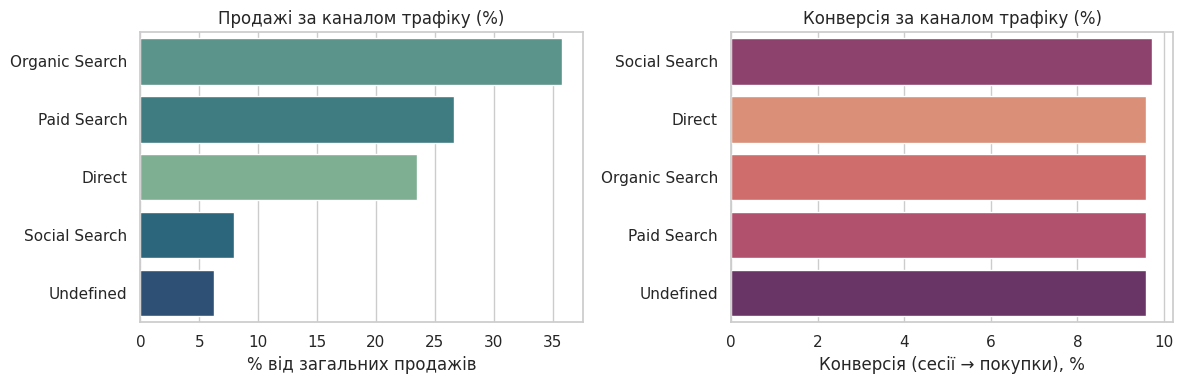

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=channel_sales, x='pct', y='traffic_channel',
            hue='traffic_channel', order=channel_sales["traffic_channel"],
            dodge=False, palette='crest', legend=False, ax=axes[0])
axes[0].set_title('Продажі за каналом трафіку (%)')
axes[0].set_xlabel('% від загальних продажів')
axes[0].set_ylabel('')

sns.barplot(data=conversion, x='conversion_rate', y='traffic_channel',
            hue='traffic_channel', order=conversion["traffic_channel"],
            dodge=False, palette='flare', legend=False, ax=axes[1])
axes[1].set_title('Конверсія за каналом трафіку (%)')
axes[1].set_xlabel('Конверсія (сесії → покупки), %')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

> **Висновок:** органічний пошук (**Organic Search**) домінує за загальною сумою продажів (**35.8%**), випереджаючи **Paid Search** (**26.6%**) та **Direct** (**23.4%**), тоді як **Social Search** та **Undefined** формують найменші частки (**7.9%** і **6.3%**); водночас конверсія сесій у покупки виявилась практично однаковою для всіх каналів (**~9.58%**), за винятком **Social Search** (**9.73%**) — тобто різниця в продажах між каналами пояснюється виключно обсягом трафіку, а не якістю відвідувачів, тож збільшення інвестицій у будь-який канал не гарантує вищої ефективності конверсії, а лише пропорційно збільшить кількість продажів відповідно до залученого трафіку.

## 4. Аналіз зареєстрованих користувачів

In [ ]:
# Тільки зареєстровані користувачі (унікальні за account_id)
registered_users = df[df['account_id'].notna()].copy()
registered_users = registered_users.drop_duplicates(subset='account_id')

print(f"Кількість зареєстрованих користувачів: {registered_users['account_id'].nunique():,}")

# 1. Підтвердили email %
email_counts = registered_users['is_email_confirmed'].value_counts()
email_confirmed_pct = registered_users['is_email_confirmed'].mean() * 100
print(f"\n1. Підтвердили email: {email_confirmed_pct:.2f}%")

# 2. Відписалися від розсилки %
unsub_counts = registered_users['is_unsubscribed'].value_counts()
unsubscribed_pct = registered_users['is_unsubscribed'].mean() * 100
print(f"2. Відписалися від розсилки: {unsubscribed_pct:.2f}%")

# 3. Продажі за статусом підписки на розсилку
registered_orders = df_orders[df_orders['account_id'].notna()].copy()
sales_by_sub = registered_orders.groupby('is_unsubscribed', observed=True)['product_price'].agg(
    total_sales='sum', avg_order_value='mean'
).reset_index()

users_by_sub = registered_users.groupby('is_unsubscribed', observed=True)['account_id'].nunique().reset_index(name='user_count')

comparison = sales_by_sub.merge(users_by_sub, on='is_unsubscribed')
comparison['sales_per_user'] = (comparison['total_sales'] / comparison['user_count']).round(2)
comparison['label'] = comparison['is_unsubscribed'].map({True: 'Відписані', False: 'Підписані'})

print("\n3. Продажі за статусом підписки на розсилку:")
for _, row in comparison.iterrows():
  label = "Відписані" if row['is_unsubscribed'] else "Підписані"
  print(f"{label}: {int(row['user_count']):,} користувачів, ${row['sales_per_user']} продажів/користувача, {row['avg_order_value']:.2f} середній чек")


# 4. Продажі за статусом підтвердження email
sales_by_email = registered_orders.groupby('is_email_confirmed', observed=True)['product_price'].agg(
    total_sales='sum', avg_order_value='mean'
).reset_index()

users_by_email = registered_users.groupby('is_email_confirmed', observed=True)['account_id'].nunique().reset_index(name='user_count')

comparison_email = sales_by_email.merge(users_by_email, on='is_email_confirmed')
comparison_email['sales_per_user'] = (comparison_email['total_sales'] / comparison_email['user_count']).round(2)
comparison_email['label'] = comparison_email['is_email_confirmed'].map({True: 'Підтвердили', False: 'Не підтвердили'})

print("\n4. Продажі за статусом підтвердження email:")
for _, row in comparison_email.iterrows():
    label = "Підтвердили" if row['is_email_confirmed'] else "Не підтвердили"
    print(f"{label}: {int(row['user_count']):,} користувачів, ${row['sales_per_user']} продажів/користувача, {row['avg_order_value']:.2f} середній чек")


# 5. Топ-10 країн за кількістю зареєстрованих користувачів
top_countries = registered_users.groupby('country', observed=True)['account_id'].nunique() \
  .sort_values(ascending=False).head(10).reset_index(name='registered_count')

print("\n5. Топ-10 країн за кількістю зареєстрованих користувачів:")
for _, row in top_countries.iterrows():
  print(f"{row['country'] + ':':<20} {row['registered_count']:>8,}")

Кількість зареєстрованих користувачів: 27,945

1. Підтвердили email: 71.70%
2. Відписалися від розсилки: 16.94%

3. Продажі за статусом підписки на розсилку:
Підписані: 23,210 користувачів, $92.67 продажів/користувача, 921.51 середній чек
Відписані: 4,735 користувачів, $91.18 продажів/користувача, 965.82 середній чек

4. Продажі за статусом підтвердження email:
Не підтвердили: 7,909 користувачів, $90.59 продажів/користувача, 904.67 середній чек
Підтвердили: 20,036 користувачів, $93.13 продажів/користувача, 938.17 середній чек

5. Топ-10 країн за кількістю зареєстрованих користувачів:
United States:         12,384
India:                  2,687
Canada:                 2,067
United Kingdom:           859
France:                   553
Spain:                    536
Taiwan:                   500
China:                    490
Germany:                  490
Italy:                    386


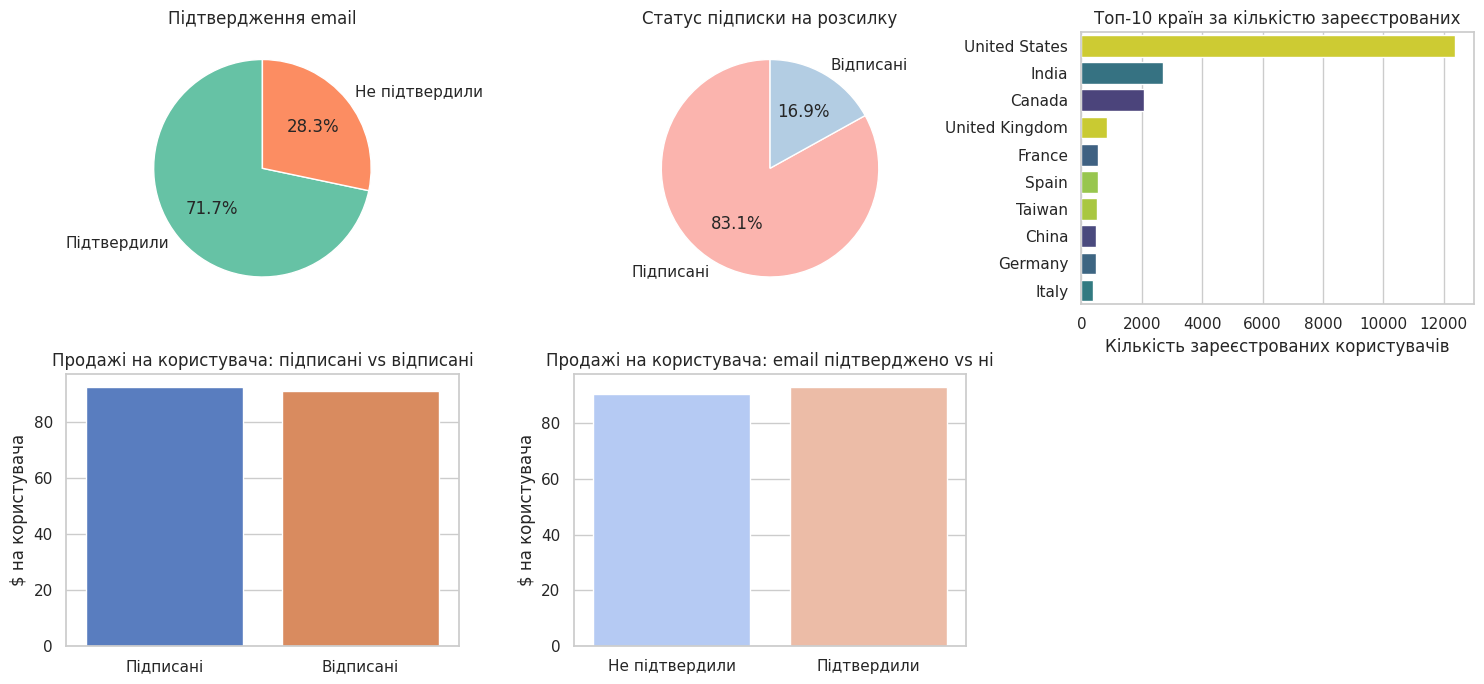

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

# 1. Підтвердження email
axes[0,0].pie(email_counts.values,
              labels=['Підтвердили' if v else 'Не підтвердили' for v in email_counts.index],
              autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=90)
axes[0,0].set_title('Підтвердження email')

# 2. Статус підписки
axes[0,1].pie(unsub_counts.values,
              labels=['Відписані' if v else 'Підписані' for v in unsub_counts.index],
              autopct='%1.1f%%', colors=sns.color_palette('Pastel1'), startangle=90)
axes[0,1].set_title('Статус підписки на розсилку')

# 3. Топ-10 країн
sns.barplot(data=top_countries, x='registered_count', y='country', hue='country',
            order=top_countries['country'], dodge=False, palette='viridis', legend=False, ax=axes[0,2])
axes[0,2].set_title('Топ-10 країн за кількістю зареєстрованих')
axes[0,2].set_xlabel('Кількість зареєстрованих користувачів')
axes[0,2].set_ylabel('')

# 4. Продажі на користувача: підписані vs відписані
sns.barplot(data=comparison, x='label', y='sales_per_user', hue='label',
            palette='muted', legend=False, ax=axes[1,0])
axes[1,0].set_title('Продажі на користувача: підписані vs відписані')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('$ на користувача')

# 5. Продажі на користувача: підтвердили email vs ні
sns.barplot(data=comparison_email, x='label', y='sales_per_user', hue='label',
            palette='coolwarm', legend=False, ax=axes[1,1])
axes[1,1].set_title('Продажі на користувача: email підтверджено vs ні')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('$ на користувача')

# Приховуємо порожній 6-й слот
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

> **Висновок:** **71.7%** зареєстрованих користувачів підтвердили email, тоді як **16.9%** відписалися від розсилки; порівняння поведінки показало **несуттєву різницю** за статусом підписки — підписані користувачі приносять **\$92.67** продажів на людину проти **\$91.18** у відписаних (менше 2%), хоча середній чек у відписаних навіть трохи **вищий** (**\$965.82** проти **\$921.51**), тобто відписка від розсилки **не пов'язана** зі зниженням купівельної активності. Натомість статус підтвердження email показав **помітнішу** різницю: користувачі, які підтвердили email, приносять **\$93.13** проти **\$90.59** у непідтверджених (+2.8%), а середній чек у них вищий на **+3.7%** (**\$938.17** проти **\$904.67**) — можливо, підтвердження email є непрямим сигналом вищої залученості до платформи. Щодо географії — **United States** домінує і тут (12 384 зареєстрованих користувачі, 44% від загальної кількості), узгоджуючись із попередніми висновками про лідерство цього ринку. **Важливе застереження:** оскільки `account_id` фіксується лише в сесії реєстрації, ці показники відображають поведінку користувачів **саме в момент реєстрації**, а не їхню сукупну активність за весь час взаємодії із сайтом.

## 5. Аналіз динаміки продажів

### 5.1 Загальна динаміка та сезонність продажів

In [ ]:
# Продажі за кожну дату (лише дати, де реально відбулись продажі)
daily_sales = df_orders.groupby('session_date')['product_price'].sum().reset_index(name='total_sales')

# Ковзне 7-денне середнє для згладження тренду
daily_sales['rolling_7d'] = daily_sales['total_sales'].rolling(window=7, center=True).mean()

print(f"Кількість дат із продажами: {daily_sales.shape[0]}")
print(f"Середні продажі за день: ${daily_sales['total_sales'].mean():,.2f}")

# Знаходимо мінімум
min_sales = daily_sales.loc[daily_sales['total_sales'].idxmin()]
print(f"\nМінімум: ${min_sales['total_sales']:,.2f} ({min_sales['session_date'].date()})")

# Знаходимо максимум
max_sales = daily_sales.loc[daily_sales['total_sales'].idxmax()]
print(f"Максимум: ${max_sales['total_sales']:,.2f} ({max_sales['session_date'].date()})")

# Знаходимо пік у грудні та січні
december_sales = daily_sales[daily_sales['session_date'].dt.month == 12]
december_peak = december_sales.loc[december_sales['total_sales'].idxmax()]
print(f"Грудневий пік: ${december_peak['total_sales']:,.2f} ({december_peak['session_date'].date()})")

january_sales = daily_sales[daily_sales['session_date'].dt.month == 1]
january_peak = january_sales.loc[january_sales['total_sales'].idxmax()]
print(f"Січневий пік: ${january_peak['total_sales']:,.2f} ({january_peak['session_date'].date()})")

print(f"\nОстанній день із продажами: {daily_sales['session_date'].max().date()}")
print(f"Загальний період у датасеті: {df['session_date'].min().date()} — {df['session_date'].max().date()}")

Кількість дат із продажами: 88
Середні продажі за день: $363,315.13

Мінімум: $200,892.20 (2020-11-07)
Максимум: $680,509.50 (2020-12-08)
Грудневий пік: $680,509.50 (2020-12-08)
Січневий пік: $609,763.80 (2021-01-06)

Останній день із продажами: 2021-01-27
Загальний період у датасеті: 2020-11-01 — 2021-01-31


In [ ]:
daily_sales['day_of_week'] = daily_sales['session_date'].dt.day_name()
daily_sales['day_of_week_num'] = daily_sales['session_date'].dt.dayofweek

dow_sales = daily_sales.groupby(['day_of_week_num', 'day_of_week'], observed=True)['total_sales'].mean().reset_index()
dow_sales = dow_sales.sort_values(by='day_of_week_num')

print("Середні продажі за днем тижня:")
for _, row in dow_sales.iterrows():
  sales_str = f"${row['total_sales']:,.2f}"
  print(f"{row['day_of_week']:<12} {sales_str:>16}")

Середні продажі за днем тижня:
Monday            $356,637.72
Tuesday           $419,808.92
Wednesday         $420,503.30
Thursday          $411,411.30
Friday            $376,922.27
Saturday          $289,832.58
Sunday            $267,183.71


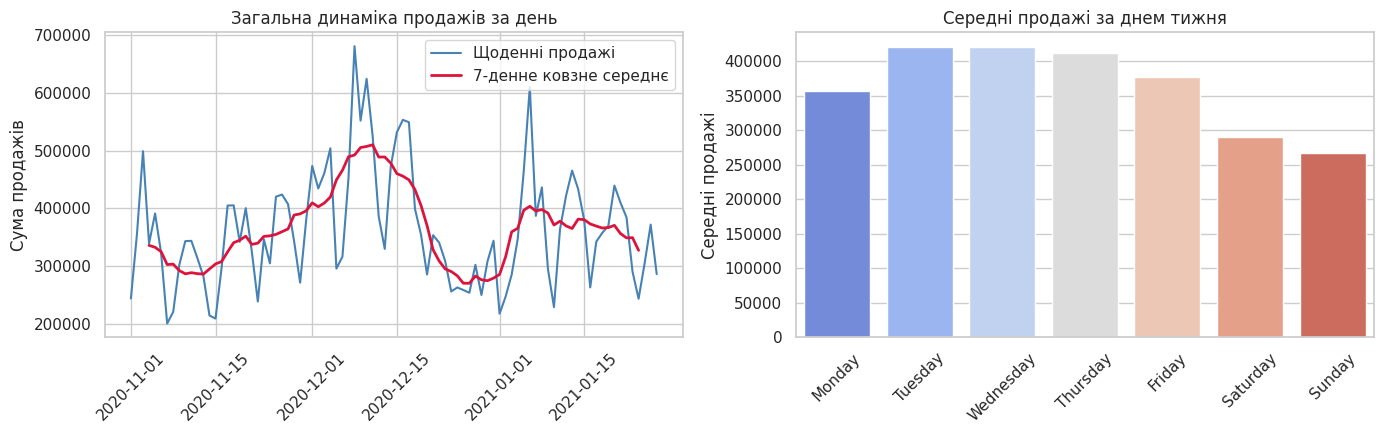

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.lineplot(data=daily_sales, x='session_date', y='total_sales', ax=axes[0], color='steelblue', linewidth=1.5, label='Щоденні продажі')
sns.lineplot(data=daily_sales, x='session_date', y='rolling_7d', ax=axes[0], color='crimson', linewidth=2, label='7-денне ковзне середнє')
axes[0].set_title('Загальна динаміка продажів за день')
axes[0].set_xlabel('')
axes[0].set_ylabel('Сума продажів')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

sns.barplot(data=dow_sales, x='day_of_week', y='total_sales', hue='day_of_week',
            order=dow_sales['day_of_week'], dodge=False, palette='coolwarm', legend=False, ax=axes[1])
axes[1].set_title('Середні продажі за днем тижня')
axes[1].set_xlabel('')
axes[1].set_ylabel('Середні продажі')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> **Висновок:** продажі зафіксовано за **88** дат у межах періоду спостереження (1 листопада 2020 — 27 січня 2021, останній день із даними). Щоденні продажі коливаються від **\$200,892** (мінімум, **7 листопада**) до **\$680,509** (пік, **8 грудня**, ймовірно передноворічний сезон), із другим піком **6 січня** (**\$609,764**, післясвяткові розпродажі) та середнім значенням **\$363,315**. Ковзне 7-денне середнє чітко виявляє плавне зростання до грудневого піку, спад у різдвяний тиждень і повторне, менш виражене зростання на початку січня. Сезонність **чітко простежується на рівні днів тижня**: продажі систематично вищі у будні (пік **вівторок-середа**, ~\$420K) і суттєво падають у вихідні (**неділя** — мінімум, ~\$267K, майже вдвічі менше піку), що типово для e-commerce.

### 5.2 Динаміка продажів за континентами

In [ ]:
# Топ-3 континенти (з розділу 3.1)
top3_continents = ['Americas', 'Asia', 'Europe']

# Продажі за датою та континентом, лише для топ-3
continent_daily = (df_orders[df_orders['continent'].isin(top3_continents)]
  .groupby(['session_date', 'continent'], observed=True)['product_price'].sum()
  .reset_index(name='total_sales')
)

print("\nСередні продажі за день по континентах:")
avg_by_continent = continent_daily.groupby('continent', observed=True)['total_sales'].mean().sort_values(ascending=False)
for cont, val in avg_by_continent.items():
  print(f"{cont:<10} {'$' + format(val, ',.2f'):>12}")


Середні продажі за день по континентах:
Americas    $200,741.82
Asia         $86,378.39
Europe       $67,438.91


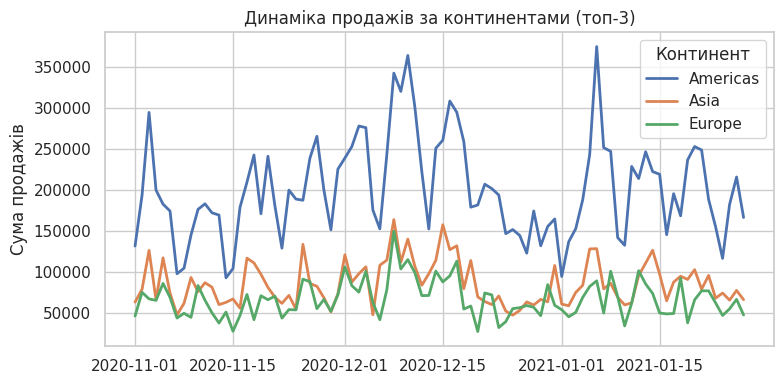

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(data=continent_daily, x='session_date', y='total_sales', hue='continent',
             hue_order=top3_continents, linewidth=2, ax=ax)
ax.set_title('Динаміка продажів за континентами (топ-3)')
ax.set_xlabel('')
ax.set_ylabel('Сума продажів')
plt.xticks(rotation=0)
plt.legend(title='Континент')

plt.tight_layout()
plt.show()

> **Висновок:** **Americas** послідовно домінує над обома іншими континентами протягом усього періоду (середнє **\$200,742** на день) — приблизно вдвічі більше за **Asia** (**\$86,378**) і майже втричі більше за **Europe** (**\$67,439**), що повністю узгоджується з висновками розділу 3.1. Усі три континенти демонструють **синхронну динаміку** — піки й спади відбуваються **одночасно** (грудневий сплеск, спад у різдвяний тиждень, січневе відновлення), що свідчить про **спільні, глобальні фактори** сезонності (ймовірно, календарні свята), а не про локальні регіональні особливості кожного ринку окремо.

### 5.3 Динаміка продажів за каналами трафіку

In [ ]:
# Усі канали трафіку (з розділу 3.4)
channels = df_orders['traffic_channel'].unique().tolist()
print("Канали трафіку:", channels)

# Продажі за датою та каналом трафіку
channel_daily = (df_orders
  .groupby(['session_date', 'traffic_channel'], observed=True)['product_price'].sum()
  .reset_index(name='total_sales')
)

# Перевірка на відсутність нульових рядків
zero_rows = (channel_daily['total_sales'] == 0).sum()
assert zero_rows == 0, f"Знайдено {zero_rows} рядків з нульовими продажами — перевір логіку розрахунку середнього!"
print(f"Перевірка пройдена: нульових рядків немає ({zero_rows})")

# Рахуємо середнє без фільтрації > 0
# (такий фільтр завищив би .mean(), виключивши "порожні" дні зі знаменника)
print("\nСередні продажі за день по каналах трафіку:")
avg_by_channel = channel_daily.groupby('traffic_channel', observed=True)['total_sales'].mean().sort_values(ascending=False)
for ch, val in avg_by_channel.items():
  print(f"{ch:<20} {'$' + format(val, ',.2f'):>12}")

Канали трафіку: ['Paid Search', 'Organic Search', 'Direct', 'Undefined', 'Social Search']
Перевірка пройдена: нульових рядків немає (0)

Середні продажі за день по каналах трафіку:
Organic Search        $129,922.18
Paid Search            $96,716.47
Direct                 $85,169.58
Social Search          $28,773.93
Undefined              $22,732.97


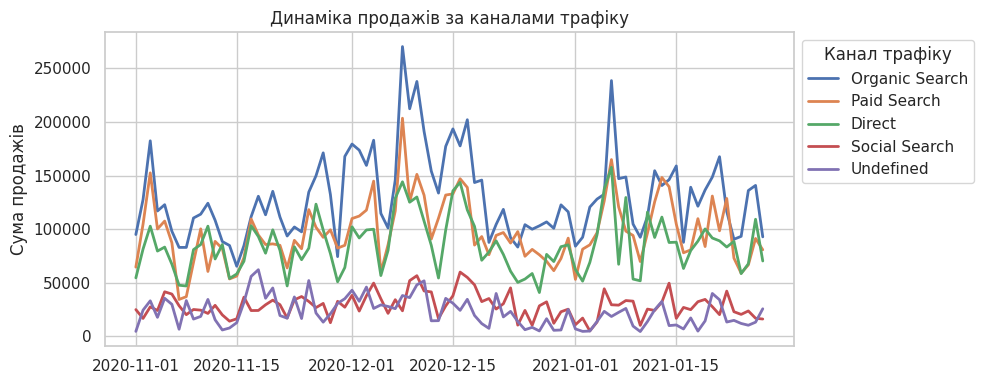

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(data=channel_daily, x='session_date', y='total_sales', hue='traffic_channel',
             hue_order=avg_by_channel.index.tolist(), linewidth=2, ax=ax)
ax.set_title('Динаміка продажів за каналами трафіку')
ax.set_xlabel('')
ax.set_ylabel('Сума продажів')
plt.xticks(rotation=0)
plt.legend(title='Канал трафіку', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

> **Висновок:** **Organic Search** послідовно лідирує серед усіх каналів трафіку (середнє **\$129,922** на день), суттєво випереджаючи **Paid Search** (**\$96,716**) та **Direct** (**\$85,170**), тоді як **Social Search** (**\$28,774**) і **Undefined** (**\$22,733**) формують значно менші, майже однакові за масштабом обсяги. Усі п'ять каналів демонструють **синхронну динаміку** з тими самими двома піками (середина грудня та початок січня), що й у загальній динаміці — підтверджуючи висновок із попередніх розділів: сезонність зумовлена спільними, глобальними факторами (святковий період), а не специфічною поведінкою окремого каналу трафіку.

### 5.4 Динаміка продажів за типами девайсів

In [ ]:
# Продажі за датою та типом девайсу
device_daily = (df_orders.groupby(['session_date', 'device'], observed=True)['product_price'].sum()
  .reset_index(name='total_sales')
)

print("\nСередні продажі за день по типах девайсів:")
avg_by_device = device_daily.groupby('device', observed=True)['total_sales'].mean().sort_values(ascending=False)
for dev, val in avg_by_device.items():
  print(f"{dev:<10} {'$' + format(val, ',.2f'):>12}")


Середні продажі за день по типах девайсів:
desktop     $214,364.08
mobile      $140,729.84
tablet        $8,221.21


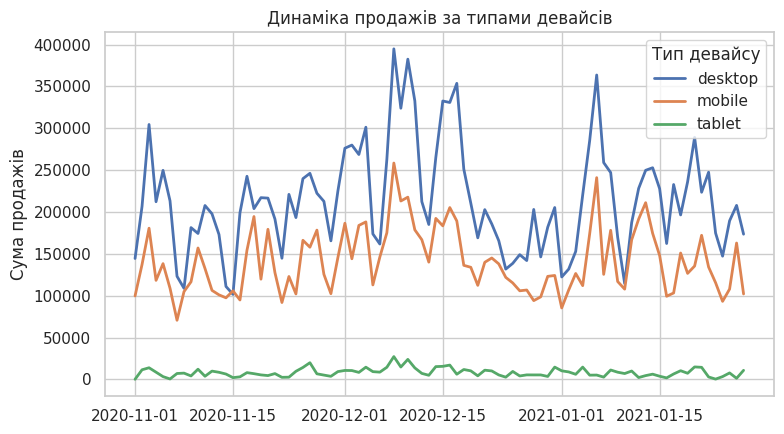

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.lineplot(data=device_daily, x='session_date', y='total_sales', hue='device',
             hue_order=avg_by_device.index.tolist(), linewidth=2, ax=ax)
ax.set_title('Динаміка продажів за типами девайсів')
ax.set_xlabel('')
ax.set_ylabel('Сума продажів')
plt.xticks(rotation=0)
plt.legend(title='Тип девайсу')

plt.tight_layout()
plt.show()

> **Висновок:** **desktop** послідовно генерує найбільше продажів (середнє **\$214,364** на день), випереджаючи **mobile** (**\$140,730**) приблизно у **1.5 раза**, тоді як **tablet** формує лише мізерну частку (**\$8,221**, майже в 26 разів менше desktop). Desktop і mobile демонструють **синхронну динаміку** з тими самими двома піками (середина грудня та початок січня), що й у загальній картині, підтверджуючи, що сезонність однаково впливає на обидва основні канали, тоді як **tablet** залишається стабільно малопомітним протягом усього періоду, без вираженої реакції на сезонні коливання.

## 6. Зведені таблиці

### 6.1 Кількість сесій за каналами трафіку та типами девайсів

In [ ]:
# Виключаємо сесії з невизначеними значеннями та пропусками
# у каналі трафіку та типі девайсу
df_known = df[
    (df["traffic_channel"] != "Undefined") &
     (df["device"] != "Undefined")
].dropna(subset=["traffic_channel", "device"])


for col in ['traffic_channel', 'device']:
  print(f"\nРеальні значення {col}:")
  print(df_known[col].unique().tolist())

  print(f"Категорії dtype ДО remove_unused_categories:")
  print(df_known[col].cat.categories.tolist())

  df_known[col] = df_known[col].cat.remove_unused_categories()

  print(f"Категорії dtype ПІСЛЯ remove_unused_categories:")
  print(df_known[col].cat.categories.tolist())

# Зведена таблиця: кількість сесій за каналом трафіку та типом девайсу
pivot_sessions = pd.pivot_table(
    df_known,
    values='session_id',
    index='traffic_channel',
    columns='device',
    aggfunc='count',
    observed=True,
    fill_value=0
)

print("\nЗведена таблиця: кількість сесій за каналом трафіку та типом девайсу")
print(pivot_sessions)

print(f"\nЗагальна кількість врахованих сесій: {pivot_sessions.values.sum():,}")
print(f"Виключено сесій з Undefined: {((df['traffic_channel'] == 'Undefined') | (df['device'] == 'Undefined')).sum():,}")


Реальні значення traffic_channel:
['Paid Search', 'Organic Search', 'Direct', 'Social Search']
Категорії dtype ДО remove_unused_categories:
['Direct', 'Organic Search', 'Paid Search', 'Social Search', 'Undefined']
Категорії dtype ПІСЛЯ remove_unused_categories:
['Direct', 'Organic Search', 'Paid Search', 'Social Search']

Реальні значення device:
['desktop', 'mobile', 'tablet']
Категорії dtype ДО remove_unused_categories:
['desktop', 'mobile', 'tablet']
Категорії dtype ПІСЛЯ remove_unused_categories:
['desktop', 'mobile', 'tablet']

Зведена таблиця: кількість сесій за каналом трафіку та типом девайсу
device           desktop  mobile  tablet
traffic_channel                         
Direct             47825   31745    1812
Organic Search     72622   49014    2789
Paid Search        55167   37034    2140
Social Search      16288   10988     638

Загальна кількість врахованих сесій: 328,062
Виключено сесій з Undefined: 21,483


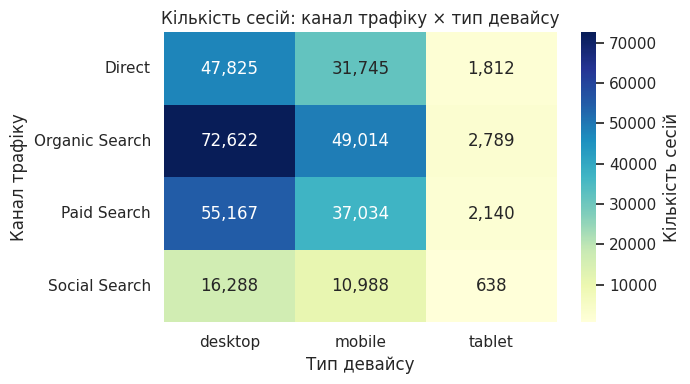

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

# print(pivot_sessions.dtypes)
# print(pivot_sessions.to_numpy().dtype)

# Перетворюємо nullable Int64 на звичайний int64,
# щоб передати heatmap числовий масив без dtype object
pivot_sessions = pivot_sessions.astype("int64")

sns.heatmap(pivot_sessions, annot=True, fmt=',d', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Кількість сесій'})
ax.set_title('Кількість сесій: канал трафіку × тип девайсу')
ax.set_xlabel('Тип девайсу')
ax.set_ylabel('Канал трафіку')

plt.tight_layout()
plt.show()

> **Висновок:** найбільша кількість сесій припадає на комбінацію **Organic Search + desktop** (**72 622 сесії**) — це домінуюча пара, що узгоджується з попередніми висновками про лідерство органічного трафіку та desktop серед каналів і типів девайсів. Загалом **desktop** переважає над **mobile** у кожному каналі трафіку, тоді як **tablet** має найменшу кількість сесій у всіх каналах — від **638 до 2 789**. Для аналізу було використано **328 062 сесії** після виключення **21 483 сесій (6,1%)** із невизначеним каналом трафіку (`Undefined`).

### 6.2 Продажі за топ-10 категоріями товарів у топ-5 країн

In [ ]:
# Топ-10 категорій за загальною сумою продажів
top10_categories = df_orders.groupby('product_category', observed=True)['product_price'] \
  .sum().sort_values(ascending=False).head(10).index.tolist()

# Топ-5 країн за загальною сумою продажів
top5_countries = df_orders.groupby('country', observed=True)['product_price'] \
  .sum().sort_values(ascending=False).head(5).index.tolist()

# Фільтруємо лише топ-10 категорій та топ-5 країн
df_top = df_orders[
    (df_orders['product_category'].isin(top10_categories)) &
    (df_orders['country'].isin(top5_countries))
].copy()

# Зведена таблиця: сума продажів за категоріями (рядки) та країнами (колонки)
pivot_sales = pd.pivot_table(
    df_top,
    values='product_price',
    index='product_category',
    columns='country',
    aggfunc='sum',
    observed=True,
    fill_value=0
)

# Впорядковуємо рядки та колонки відповідно до рейтингу (за спаданням)
pivot_sales = pivot_sales.reindex(index=top10_categories, columns=top5_countries)

# Діагностика типів даних: перевіряємо dtype колонок
# та dtype NumPy-масиву перед побудовою heatmap
print(pivot_sales.dtypes)
print(pivot_sales.to_numpy().dtype)

print("\nЗведена таблиця: сума продажів (категорія × країна)")
pivot_sales.round(0)

country
United States     float64
India             float64
Canada            float64
United Kingdom    float64
France            float64
dtype: object
float64

Зведена таблиця: сума продажів (категорія × країна)


country,United States,India,Canada,United Kingdom,France
product_category,,,,,
Sofas & armchairs,3707144.0,788430.0,692428.0,234812.0,187735.0
Chairs,2619774.0,544309.0,417741.0,188519.0,134029.0
Beds,2213058.0,358320.0,354772.0,133816.0,116414.0
Bookcases & shelving units,1567607.0,364507.0,278982.0,113988.0,73830.0
Cabinets & cupboards,994546.0,191888.0,181802.0,71684.0,59102.0
Outdoor furniture,929245.0,162289.0,185323.0,57002.0,40486.0
Tables & desks,777865.0,186158.0,132678.0,49374.0,42299.0
Chests of drawers & drawer units,382388.0,73111.0,71952.0,36784.0,21544.0
Bar furniture,330805.0,57657.0,51724.0,22103.0,11199.0


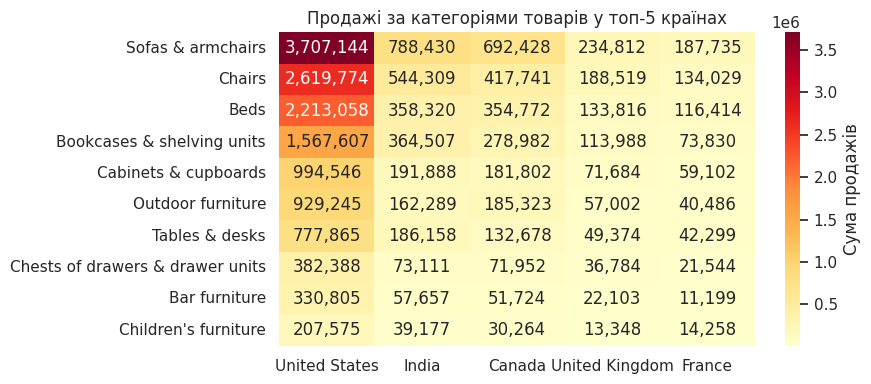

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.heatmap(pivot_sales, annot=True, fmt=',.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Сума продажів'})
ax.set_title('Продажі за категоріями товарів у топ-5 країнах')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

> **Висновок:** **United States** лідирує за продажами в усіх топ-10 категоріях, а **Sofas & armchairs** має найбільший результат (**$3.71M**). Рейтинг категорій у п'яти країнах загалом зберігається, що підтверджує висновок із розділу 3.3: споживчі вподобання суттєво не відрізняються між ринками. **India** та **Canada** мають зіставні обсяги продажів, тоді як **United Kingdom** і **France** демонструють нижчі результати, що відповідає їхнім позиціям у загальному рейтингу країн (розділ 3.1).

### 6.3 Середня вартість товарів за категоріями та типами девайсів

In [ ]:
# Виключаємо сесії з невизначеними категоріями та типом девайсу,
# а також сесії з відсутніми значеннями в цих колонках
df_category_device = df_orders[
    (df_orders["product_category"] != "Undefined") &
     (df_orders["device"] != "Undefined")
].dropna(subset=["product_category", "device"])

# Зведена таблиця: середня вартість товарів за категоріями та типами девайсів
pivot_avg_price = pd.pivot_table(
    df_category_device,
    values='product_price',
    index='product_category',
    columns='device',
    aggfunc='mean',
    observed=True,
    fill_value=0
)

# Залишаємо топ-10 категорій та впорядковуємо їх відповідно до рейтингу
pivot_avg_price = pivot_avg_price.reindex(top10_categories)

print("Зведена таблиця: середня вартість товару (топ-10 категорій × девайс)")
print(pivot_avg_price.round(2))

Зведена таблиця: середня вартість товару (топ-10 категорій × девайс)
device                            desktop   mobile   tablet
product_category                                           
Sofas & armchairs                 1939.86  1965.71  1954.04
Chairs                            1058.55   984.08  1186.81
Beds                              1708.85  1646.09  1612.55
Bookcases & shelving units         479.98   473.54   468.12
Cabinets & cupboards              1001.67  1006.66  1201.67
Outdoor furniture                  958.85   961.09  1023.43
Tables & desks                     610.18   610.24   551.22
Chests of drawers & drawer units   627.39   617.69   668.26
Bar furniture                      668.83   686.38   583.08
Children's furniture               276.46   269.90   319.91


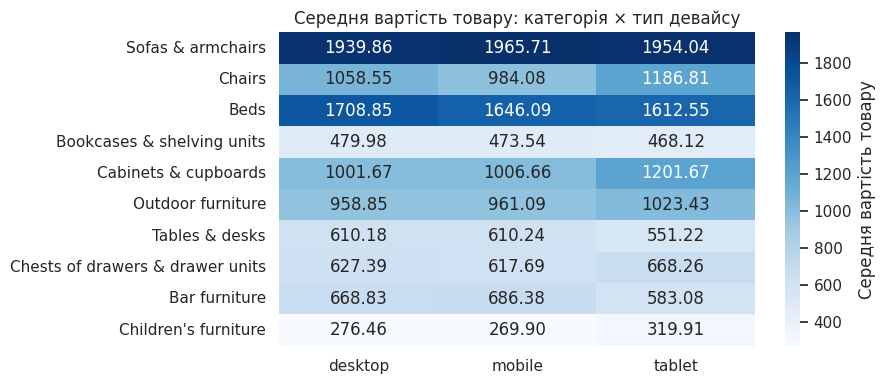

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.heatmap(pivot_avg_price, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar_kws={'label': 'Середня вартість товару'})
ax.set_title('Середня вартість товару: категорія × тип девайсу')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

> **Висновок:** середня вартість товару **практично не залежить від типу девайсу** — різниця між **desktop/mobile/tablet** зазвичай не перевищує 5-10% у межах кожної категорії (наприклад, **Sofas & armchairs**: **\$1939.86** vs **\$1965.71** vs **\$1954.04**), що спростовує гіпотезу про схильність **mobile**-користувачів до дешевших покупок. Найбільша варіативність — у **Cabinets & cupboards**, де **tablet**-користувачі купують дорожчі товари (**\$1201.67** проти ~**\$1000** на **desktop/mobile**), хоча це може бути статистичним шумом через малу кількість замовлень із планшетів.

## 7. Статистичний аналіз взаємозв'язків

### 7.1 Кореляція між кількістю сесій та продажами

In [ ]:
from scipy import stats

# Кількість сесій за кожну дату (усі сесії, не лише з покупкою)
sessions_daily = df.groupby('session_date')['session_id'].nunique().reset_index(name='session_count')

# Продажі за кожну дату
sales_daily = df_orders.groupby('session_date')['product_price'].sum().reset_index(name='total_sales')

# Об'єднуємо в один датафрейм та сортуємо за датою
merged = sessions_daily.merge(sales_daily, on='session_date', how='inner') \
  .sort_values('session_date').reset_index(drop=True) # скидаємо індекс після сортування

print(merged.tail(5))

# Перевірка нормальності розподілу (тест Шапіро-Вілка)
stat1, p_norm1 = stats.shapiro(merged['session_count'])
stat2, p_norm2 = stats.shapiro(merged['total_sales'])

print(f"\nНормальність session_count: W={stat1:.4f}, p={p_norm1:.4f} ({'нормальний' if p_norm1 > 0.05 else 'НЕ нормальний'})")
print(f"Нормальність total_sales:   W={stat2:.4f}, p={p_norm2:.4f} ({'нормальний' if p_norm2 > 0.05 else 'НЕ нормальний'})")

# Оскільки обидва розподіли відхиляються від нормальності — рахуємо і Пірсона, і Спірмена
pearson_corr, pearson_p = stats.pearsonr(merged['session_count'], merged['total_sales'])
spearman_corr, spearman_p = stats.spearmanr(merged['session_count'], merged['total_sales'])

print(f"\nКореляція Пірсона:  r={pearson_corr:.4f}, p={pearson_p:.2e}")
print(f"Статистично значуща (alpha=0.05): {'Так' if pearson_p < 0.05 else 'Ні'}")

print(f"\nКореляція Спірмена: rho={spearman_corr:.4f}, p={spearman_p:.2e}")
print(f"Статистично значуща (alpha=0.05): {'Так' if spearman_p < 0.05 else 'Ні'}")

   session_date  session_count  total_sales
83   2021-01-23           3067     290605.5
84   2021-01-24           2893     243818.4
85   2021-01-25           3760     305089.3
86   2021-01-26           3970     372057.3
87   2021-01-27           4435     286340.7

Нормальність session_count: W=0.9701, p=0.0395 (НЕ нормальний)
Нормальність total_sales:   W=0.9563, p=0.0048 (НЕ нормальний)

Кореляція Пірсона:  r=0.9313, p=1.74e-39
Статистично значуща (alpha=0.05): Так

Кореляція Спірмена: rho=0.9043, p=1.54e-33
Статистично значуща (alpha=0.05): Так


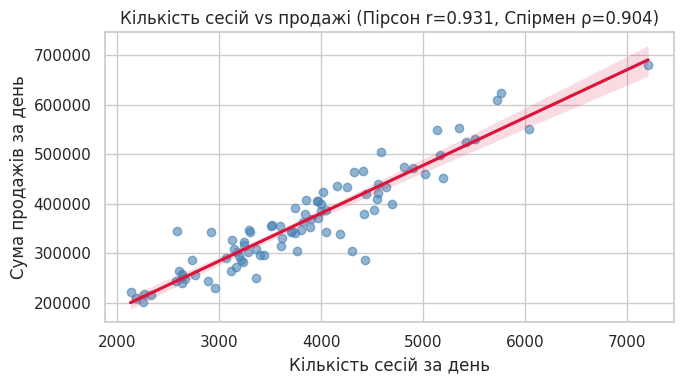

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.regplot(data=merged, x='session_count', y='total_sales', ax=ax,
            scatter_kws={'alpha': 0.6, 'color': 'steelblue'}, line_kws={'color': 'crimson'})

ax.set_title(f'Кількість сесій vs продажі (Пірсон r={pearson_corr:.3f}, Спірмен ρ={spearman_corr:.3f})')
ax.set_xlabel('Кількість сесій за день')
ax.set_ylabel('Сума продажів за день')

plt.tight_layout()
plt.show()

> **Висновок:** тест **Шапіро–Вілка** показав, що обидві змінні — кількість сесій та сума продажів — **статистично значуще відхиляються від нормального розподілу** (**p<0.05**). Тому для повноти розраховано як параметричний коефіцієнт **Пірсона** (**r=0.9313**), так і непараметричний коефіцієнт **Спірмена** (**rho=0.9043**). Обидва методи показали **дуже сильну позитивну кореляцію**, статистично високо значущу (**p<0.001** в обох випадках). Близькі результати двох методів підтверджують **стійкість висновку**: кількість сесій дуже тісно пов'язана із сумою продажів, а відхилення від нормальності не змінює загальної картини взаємозв'язку між метриками.

### 7.2 Кореляція продажів між континентами

In [ ]:
# Топ-3 континенти
top3_continents = df_orders.groupby('continent', observed=True)['product_price'].sum().sort_values(ascending=False).head(3).index.tolist()

# Продажі за датою та континентом, у "широкому" форматі (кожен континент - окрема колонка)
continent_daily = df_orders[df_orders['continent'].isin(top3_continents)].groupby(
    ['session_date', 'continent'], observed=True
)['product_price'].sum().reset_index(name='total_sales')

continent_wide = continent_daily.pivot(index='session_date', columns='continent', values='total_sales').fillna(0)
continent_wide.columns.name = None

# Перевірка нормальності для кожного континенту
print("Перевірка нормальності (тест Шапіро-Вілка):")
for cont in top3_continents:
  stat, p = stats.shapiro(continent_wide[cont])
  print(f"{cont:<10} W={stat:.4f}, p={p:.4f} ({'нормальний' if p > 0.05 else 'НЕ нормальний'})")

# Усі три розподіли НЕ нормальні - використовуємо кореляцію Спірмена
print("\nКореляція Спірмена між континентами:")
pairs = [('Americas', 'Asia'), ('Americas', 'Europe'), ('Asia', 'Europe')]
for c1, c2 in pairs:
  corr, p = stats.spearmanr(continent_wide[c1], continent_wide[c2])
  sig = "Так" if p < 0.05 else "Ні"
  print(f"{c1} vs {c2}: rho={corr:.4f}, p={p:.2e}, значуща={sig}")

Перевірка нормальності (тест Шапіро-Вілка):
Americas   W=0.9706, p=0.0425 (НЕ нормальний)
Asia       W=0.9379, p=0.0004 (НЕ нормальний)
Europe     W=0.9592, p=0.0073 (НЕ нормальний)

Кореляція Спірмена між континентами:
Americas vs Asia: rho=0.6685, p=1.10e-12, значуща=Так
Americas vs Europe: rho=0.6259, p=7.01e-11, значуща=Так
Asia vs Europe: rho=0.6082, p=3.27e-10, значуща=Так


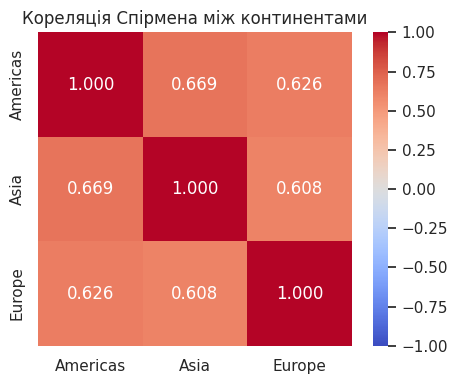

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

corr_matrix = continent_wide[top3_continents].corr(method='spearman')

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Кореляція Спірмена між континентами')

plt.tight_layout()
plt.show()

> **Висновок:** усі три континенти мають розподіл продажів, що статистично значущо відхиляється від нормального (**Shapiro–Wilk, p<0.05**), тому використано рангову кореляцію **Спірмена**. Усі пари демонструють помірну статистично значущу позитивну кореляцію: **Americas–Asia** (**rho=0.669**, найсильніша), **Americas–Europe** (**rho=0.626**) та **Asia–Europe** (**rho=0.608**), **p<0.001** для всіх пар. Це підтверджує висновок з **5.2** про синхронність продажів, зокрема під впливом спільної сезонності у святковий період. Водночас сила зв'язку є помірною (**rho=0.60–0.67**), а не сильною, як у **7.1**, що може свідчити про вплив локальних факторів на динаміку продажів у різних регіонах.

### 7.3 Кореляція продажів між каналами трафіку

In [ ]:
from itertools import combinations

# Топ каналів трафіку за сумою продажів
channels = df_orders.groupby('traffic_channel', observed=True)['product_price'].sum().sort_values(ascending=False).index.tolist()

# Продажі за датою та каналом трафіку у "довгому" форматі (long)
channel_daily = df_orders.groupby(
    ['session_date', 'traffic_channel'], observed=True
)['product_price'].sum().reset_index(name='total_sales')

# Розвертаємо в "широкий" формат (wide) - кожен канал стає окремою колонкою
channel_wide = channel_daily.pivot(index='session_date', columns='traffic_channel', values='total_sales').fillna(0)
channel_wide.columns.name = None

# Перевірка нормальності для кожного каналу трафіку (тест Шапіро-Вілка)
print("Перевірка нормальності (тест Шапіро-Вілка):")
normality_results = {}
for channel in channels:
  stat, p = stats.shapiro(channel_wide[channel])
  normality_results[channel] = p
  print(f"{channel:<15} W={stat:.4f}, p={p:.4f} ({'нормальний' if p > 0.05 else 'НЕ нормальний'})")

all_normal = all(p > 0.05 for p in normality_results.values())
corr_method = 'pearson' if all_normal else 'spearman'
method_name = 'Пірсона' if corr_method == 'pearson' else 'Спірмена'
print(f"\nОбраний метод кореляції: {method_name}")

# Кореляція між усіма парами каналів
symbol = 'r' if corr_method == 'pearson' else 'rho'
print(f"\nКореляція {method_name} між каналами трафіку:")

pairs = list(combinations(channels, 2))
for c1, c2 in pairs:
  if corr_method == 'pearson':
    corr, p = stats.pearsonr(channel_wide[c1], channel_wide[c2])
  else:
    corr, p = stats.spearmanr(channel_wide[c1], channel_wide[c2])
  sig = "Так" if p < 0.05 else "Ні"
  print(f"{c1} vs {c2}: {symbol}={corr:.4f}, p={p:.2e}, значуща={sig}")

Перевірка нормальності (тест Шапіро-Вілка):
Organic Search  W=0.9268, p=0.0001 (НЕ нормальний)
Paid Search     W=0.9649, p=0.0174 (НЕ нормальний)
Direct          W=0.9627, p=0.0125 (НЕ нормальний)
Social Search   W=0.9767, p=0.1131 (нормальний)
Undefined       W=0.9437, p=0.0008 (НЕ нормальний)

Обраний метод кореляції: Спірмена

Кореляція Спірмена між каналами трафіку:
Organic Search vs Paid Search: rho=0.7639, p=4.86e-18, значуща=Так
Organic Search vs Direct: rho=0.7482, p=5.36e-17, значуща=Так
Organic Search vs Social Search: rho=0.3848, p=2.14e-04, значуща=Так
Organic Search vs Undefined: rho=0.4569, p=7.65e-06, значуща=Так
Paid Search vs Direct: rho=0.6908, p=9.51e-14, значуща=Так
Paid Search vs Social Search: rho=0.4204, p=4.54e-05, значуща=Так
Paid Search vs Undefined: rho=0.4933, p=1.05e-06, значуща=Так
Direct vs Social Search: rho=0.3937, p=1.48e-04, значуща=Так
Direct vs Undefined: rho=0.4937, p=1.02e-06, значуща=Так
Social Search vs Undefined: rho=0.3859, p=2.05e-04, значуща

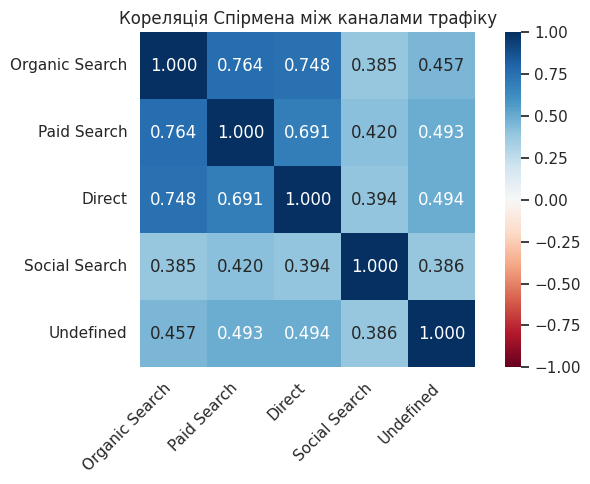

In [ ]:
# Матриця кореляції та теплова карта
corr_matrix = channel_wide[channels].corr(method=corr_method)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title(f'Кореляція {method_name} між каналами трафіку')

ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

> **Висновок:** чотири з п'яти каналів мають розподіл, що статистично значущо відхиляється від нормального (**Shapiro–Wilk, p<0.05**), і лише **Social Search** не має підстав відхилятися від нормальності (**p=0.1131**). Тому для всіх пар використано рангову кореляцію **Спірмена**. Усі 10 пар демонструють статистично значущу позитивну кореляцію (**p<0.001**). Найсильніший зв'язок спостерігається між **Organic Search–Paid Search** (**rho=0.764**) та **Organic Search–Direct** (**rho=0.748**), дещо слабший — між **Paid Search–Direct** (**rho=0.691**). Отже, ці три канали мають найбільш схожу динаміку продажів. **Social Search** та **Undefined** демонструють помітно слабші зв'язки з іншими каналами (**rho=0.38–0.49**), що свідчить про менш схожу динаміку їхніх продажів порівняно з основними каналами.

### 7.4 Кореляція продажів між категоріями товарів

In [ ]:
from itertools import combinations

# Топ-5 категорій товарів за сумою продажів
top5_categories = df_orders.groupby('product_category', observed=True)['product_price'].sum() \
  .sort_values(ascending=False).head(5).index.tolist()

print("Топ-5 категорій за сумою продажів:")
print(top5_categories)

# Продажі за датою та категорією товару у "довгому" форматі (long), лише топ-5 категорій
category_daily = (df_orders[df_orders['product_category'].isin(top5_categories)] \
  .groupby(['session_date', 'product_category'], observed=True)['product_price'].sum().reset_index(name='total_sales'))

# Розвертаємо в "широкий" формат (wide) - кожна категорія стає окремою колонкою
category_wide = category_daily.pivot(index='session_date', columns='product_category', values='total_sales').fillna(0)
category_wide.columns.name = None

# Перевірка нормальності для кожної категорії товару (тест Шапіро-Вілка)
print("\nПеревірка нормальності (тест Шапіро-Вілка):")
normality_results = {}
for category in top5_categories:
  stat, p = stats.shapiro(category_wide[category])
  normality_results[category] = p
  print(f"{category:<15} W={stat:.4f}, p={p:.4f} ({'нормальний' if p > 0.05 else 'НЕ нормальний'})")

all_normal = all(p > 0.05 for p in normality_results.values())
corr_method = 'pearson' if all_normal else 'spearman'
method_name = 'Пірсона' if corr_method == 'pearson' else 'Спірмена'
print(f"\nОбраний метод кореляції: {method_name}")

# Кореляція між усіма парами топ-5 категорій
symbol = 'r' if corr_method == 'pearson' else 'rho'
print(f"\nКореляція {method_name} між топ-5 категоріями товарів:")

pairs = list(combinations(top5_categories, 2))
for c1, c2 in pairs:
  if corr_method == 'pearson':
    corr, p = stats.pearsonr(category_wide[c1], category_wide[c2])
  else:
    corr, p = stats.spearmanr(category_wide[c1], category_wide[c2])
  sig = "Так" if p < 0.05 else "Ні"
  print(f"{c1} vs {c2}: {symbol}={corr:.4f}, p={p:.2e}, значуща={sig}")

Топ-5 категорій за сумою продажів:
['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards']

Перевірка нормальності (тест Шапіро-Вілка):
Sofas & armchairs W=0.9626, p=0.0122 (НЕ нормальний)
Chairs          W=0.9427, p=0.0007 (НЕ нормальний)
Beds            W=0.9502, p=0.0020 (НЕ нормальний)
Bookcases & shelving units W=0.9604, p=0.0088 (НЕ нормальний)
Cabinets & cupboards W=0.9562, p=0.0047 (НЕ нормальний)

Обраний метод кореляції: Спірмена

Кореляція Спірмена між топ-5 категоріями товарів:
Sofas & armchairs vs Chairs: rho=0.5833, p=2.46e-09, значуща=Так
Sofas & armchairs vs Beds: rho=0.5217, p=1.86e-07, значуща=Так
Sofas & armchairs vs Bookcases & shelving units: rho=0.6256, p=7.19e-11, значуща=Так
Sofas & armchairs vs Cabinets & cupboards: rho=0.6312, p=4.32e-11, значуща=Так
Chairs vs Beds: rho=0.5349, p=7.91e-08, значуща=Так
Chairs vs Bookcases & shelving units: rho=0.6368, p=2.59e-11, значуща=Так
Chairs vs Cabinets & cupboards: rho=0.5268, p=1.3

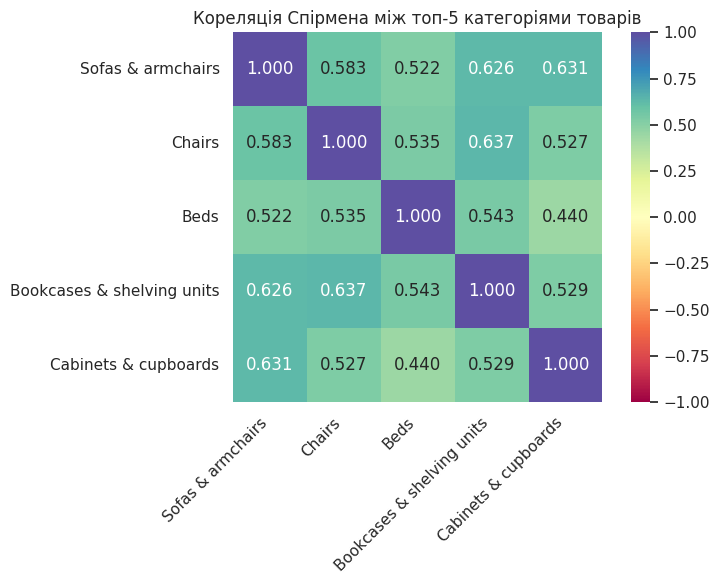

In [ ]:
# Матриця кореляції та теплова карта
corr_matrix = category_wide[top5_categories].corr(method=corr_method)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Spectral', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title(f'Кореляція {method_name} між топ-5 категоріями товарів')

ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

> **Висновок:** усі п'ять категорій статистично значущо відхиляються від нормального розподілу (**Shapiro–Wilk, p<0.05**), тому використано кореляцію **Спірмена**. Усі 10 пар мають статистично значущу помірну позитивну кореляцію (**p<0.001; ρ=0.440–0.637**). Найсильніші зв'язки — **Chairs–Bookcases & shelving units** (ρ=0.637), **Sofas & armchairs–Cabinets & cupboards** (ρ=0.631) та **Sofas & armchairs–Bookcases & shelving units** (ρ=0.626), найслабший — **Beds–Cabinets & cupboards** (ρ=0.440). Загалом категорії демонструють **відносно узгоджену динаміку продажів**, що може бути пов'язана зі спільними факторами, зокрема сезонністю.


## 8. Статистичний аналіз відмінностей між групами

### 8.1 Продажі за датою: зареєстровані vs незареєстровані користувачі

In [ ]:
# Створюємо ознаку "зареєстрований" на рівні сесій із замовленням
df_orders['has_account'] = df_orders['account_id'].notna()

# Щоденні продажі окремо для зареєстрованих та незареєстрованих користувачів
sales_by_account = df_orders.groupby(['session_date', 'has_account'], observed=True)['product_price'] \
  .sum().reset_index(name='total_sales')

# Розвертаємо в "широкий" формат (wide) - кожна група (зареєстрований/незареєстрований) стає окремою колонкою
sales_wide = sales_by_account.pivot(index='session_date', columns='has_account', values='total_sales').fillna(0)
sales_wide.columns = ['unregistered', 'registered']
sales_wide.columns.name = None

registered_sales = sales_wide['registered']
unregistered_sales = sales_wide['unregistered']

print(sales_wide.describe())

        unregistered    registered
count      88.000000     88.000000
mean   333968.325000  29346.801136
std     92910.207068  10765.451652
min    182206.200000  11779.000000
25%    270485.500000  20717.375000
50%    316724.250000  28048.000000
75%    379948.475000  35774.700000
max    612358.400000  68151.100000


In [ ]:
# Перевірка нормальності (тест Шапіро-Вілка):
# W ≈ 1 → форма розподілу схожа на нормальну
# p > 0.05 → немає підстав відхиляти нормальність
# p < 0.05 → статистично значуще відхилення від нормальності
# W ≈ 1 та p > 0.05 → розподіл нормальний (немає підстав відхиляти нормальність)
# W << 1 та p < 0.05 → статистично значуще відхилення від нормальності

stat_reg, p_reg = stats.shapiro(registered_sales)
stat_unreg, p_unreg = stats.shapiro(unregistered_sales)

print("Перевірка нормальності (тест Шапіро-Вілка):")
print(f"Зареєстровані:    W={stat_reg:.4f}, p={p_reg:.4f} ({'нормальний' if p_reg > 0.05 else 'НЕ нормальний'})")
print(f"Незареєстровані:  W={stat_unreg:.4f}, p={p_unreg:.4f} ({'нормальний' if p_unreg > 0.05 else 'НЕ нормальний'})")

both_normal = (p_reg > 0.05) and (p_unreg > 0.05)
print(f"\nОбраний тест: {'t-тест (незалежні вибірки)' if both_normal else 'Mann-Whitney U'}")

Перевірка нормальності (тест Шапіро-Вілка):
Зареєстровані:    W=0.9592, p=0.0073 (НЕ нормальний)
Незареєстровані:  W=0.9522, p=0.0026 (НЕ нормальний)

Обраний тест: Mann-Whitney U


In [ ]:
# Обираємо тест залежно від результату перевірки нормальності
if both_normal:
  stat, p = stats.ttest_ind(sales_wide['registered'], sales_wide['unregistered'])
  test_name = "t-тест для незалежних вибірок"
else:
  stat, p = stats.mannwhitneyu(registered_sales, unregistered_sales, alternative='two-sided')
  test_name = "Mann-Whitney U"

sig = "Так" if p < 0.05 else "Ні"
print(f"{test_name}: statistic={stat:.4f}, p={p:.4e}")
print(f"Статистично значуща відмінність (alpha=0.05): {sig}")

print(f"\nСередні щоденні продажі:")
mean_reg_str = f"${registered_sales.mean():,.2f}"
mean_unreg_str = f"${unregistered_sales.mean():,.2f}"
print(f"Зареєстровані:    {mean_reg_str}")
print(f"Незареєстровані:  {mean_unreg_str}")

Mann-Whitney U: statistic=0.0000, p=2.2159e-30
Статистично значуща відмінність (alpha=0.05): Так

Середні щоденні продажі:
Зареєстровані:    $29,346.80
Незареєстровані:  $333,968.33


> **Висновок:** обидві вибірки мають розподіл, що статистично значущо відхиляється від нормального (**Shapiro–Wilk, p<0.01**), тому використано непараметричний тест **Mann–Whitney U**. Виявлено статистично значущу відмінність між групами (**U=0.0, p<0.001**): середні щоденні продажі незареєстрованих користувачів (**\$333,968**) значно перевищують продажі зареєстрованих (**\$29,347**). Однак це порівняння відображає насамперед **різний обсяг трафіку**: незареєстровані сесії становлять близько **92%** усіх сесій. Для коректнішого порівняння **поведінки на рівні однієї сесії** (а не сукупного обсягу) варто додатково порівняти **середній чек** (`product_price`) між групами, а не лише сумарні щоденні продажі.

### 8.1.1 Продажі на одну сесію: середній чек зареєстрованих vs незареєстрованих

In [ ]:
registered_orders = df_orders.loc[df_orders['has_account'], 'product_price']
unregistered_orders = df_orders.loc[~df_orders['has_account'], 'product_price']

print(f"Кількість замовлень: зареєстровані={len(registered_orders)}, незареєстровані={len(unregistered_orders)}")
print(f"\n{registered_orders.describe()}")
print(f"\n{unregistered_orders.describe()}")

Кількість замовлень: зареєстровані=2781, незареєстровані=30757

count    2781.000000
mean      928.629450
std      1319.683818
min         3.000000
25%       150.000000
50%       399.000000
75%      1140.000000
max      8900.000000
Name: product_price, dtype: float64

count    30757.000000
mean       955.529232
std       1316.757708
min          3.000000
25%        175.000000
50%        445.000000
75%       1195.000000
max       9585.000000
Name: product_price, dtype: float64


In [ ]:
# Перевірка нормальності обох вибірок (тест Шапіро-Вілка)
# Для великих вибірок Shapiro-Wilk може давати неточний p-value при n > 5000;
# тому використовуємо випадкову підвибірку з 5000 спостережень
sample_size = 5000
stat_reg, p_reg = stats.shapiro(registered_orders.sample(min(sample_size, len(registered_orders)), random_state=42))
stat_unreg, p_unreg = stats.shapiro(unregistered_orders.sample(min(sample_size, len(unregistered_orders)), random_state=42))

print("Перевірка нормальності (тест Шапіро-Вілка, на підвибірці n≤5000):")
print(f"Зареєстровані:    W={stat_reg:.4f}, p={p_reg:.4f} ({'нормальний' if p_reg > 0.05 else 'НЕ нормальний'})")
print(f"Незареєстровані:  W={stat_unreg:.4f}, p={p_unreg:.4f} ({'нормальний' if p_unreg > 0.05 else 'НЕ нормальний'})")

Перевірка нормальності (тест Шапіро-Вілка, на підвибірці n≤5000):
Зареєстровані:    W=0.6657, p=0.0000 (НЕ нормальний)
Незареєстровані:  W=0.6759, p=0.0000 (НЕ нормальний)


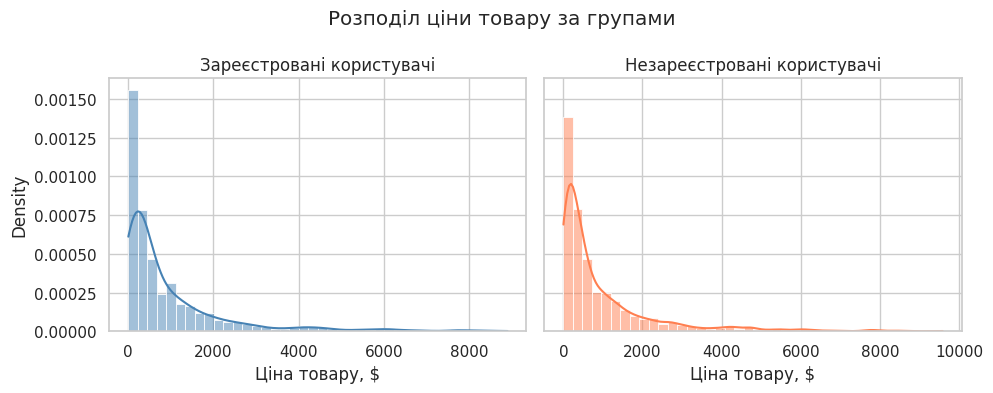

In [ ]:
# Візуалізація — додаткова перевірка форми розподілу (Shapiro-Wilk чутливий до n=33,538)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sns.histplot(registered_orders, kde=True, ax=axes[0], color='steelblue', bins=40, stat='density', common_norm=False)
axes[0].set_title('Зареєстровані користувачі')
axes[0].set_xlabel('Ціна товару, $')

sns.histplot(unregistered_orders, kde=True, ax=axes[1], color='coral', bins=40, stat='density', common_norm=False)
axes[1].set_title('Незареєстровані користувачі')
axes[1].set_xlabel('Ціна товару, $')

fig.suptitle('Розподіл ціни товару за групами')
plt.tight_layout()
plt.show()

> **Висновок:** тест Шапіро-Вілка показав виражене відхилення від нормальності в обох групах (**W≈0.67, p<0.001**), що підтверджується й візуально: гістограми демонструють яскраву правосторонню асиметрію з найбільшою концентрацією цін у діапазоні **\$0–500** та довгим правим хвостом до **\$8,000–10,000**. Форми розподілів у групах подібні, що свідчить про **схожу структуру розподілу цін незалежно від статусу реєстрації**. Оскільки нормальність відхилена однозначно, для перевірки статистично значущої різниці між групами використано непараметричний тест **Mann–Whitney U**.

In [ ]:
# Рішення про тест (враховує Shapiro-Wilk і візуальну оцінку форми розподілу)
both_normal = (p_reg > 0.05) and (p_unreg > 0.05)
print(f"Обраний тест: {'t-тест (незалежні вибірки)' if both_normal else 'Mann-Whitney U'}")

Обраний тест: Mann-Whitney U


In [ ]:
if both_normal:
  stat, p = stats.ttest_ind(registered_orders, unregistered_orders)
  test_name = "t-тест для незалежних вибірок"
else:
  stat, p = stats.mannwhitneyu(registered_orders, unregistered_orders, alternative='two-sided')
  test_name = "Mann-Whitney U"

sig = "Так" if p < 0.05 else "Ні"
print(f"{test_name}: statistic={stat:.4f}, p={p:.4e}")
print(f"Статистично значуща відмінність (alpha=0.05): {sig}")

summary_table = pd.DataFrame({
  'Середній чек': [registered_orders.mean(), unregistered_orders.mean()],
  'Медіана': [registered_orders.median(), unregistered_orders.median()]
}, index=['Зареєстровані', 'Незареєстровані'])

display(summary_table.style.format('${:,.2f}'))

Mann-Whitney U: statistic=41771375.0000, p=4.1591e-02
Статистично значуща відмінність (alpha=0.05): Так


,Середній чек,Медіана
Зареєстровані,$928.63,$399.00
Незареєстровані,$955.53,$445.00


> **Висновок:** тест **Mann–Whitney U** виявив статистично значущу відмінність між групами (**p=0.042**), хоча результат близький до порогового рівня **α=0.05**. На відміну від порівняння сумарних щоденних продажів (8.1), де незареєстровані користувачі суттєво переважали за рахунок більшого обсягу трафіку, на рівні окремої сесії різниця значно менша: середній чек незареєстрованих користувачів становить **\$955.53** проти **\$928.63** у зареєстрованих, а медіана — **\$445** проти **\$399**. Різниця становить лише близько **2.9% за середнім** та **11.5% за медіаною**, тому, попри статистичну значущість, **практична відмінність у розмірі покупки є невеликою**. Отже, основна різниця між групами, ймовірно, пов'язана не з розміром окремої покупки, а з **кількістю сесій**.

### 8.2 Кількість сесій за різними каналами трафіку

In [ ]:
# Кількість сесій за датою та каналом трафіку у "довгому" форматі (long)
sessions_channel_daily = df.groupby(['session_date', 'traffic_channel'], observed=True)['session_id'] \
  .nunique().reset_index(name='session_count')

# Розвертаємо в "широкий" формат (wide) - кожен канал стає окремою колонкою
sessions_channel_wide = sessions_channel_daily.pivot(index='session_date', columns='traffic_channel', values='session_count').fillna(0)
sessions_channel_wide.columns.name = None

sessions_channel_wide.describe()

,Direct,Organic Search,Paid Search,Social Search,Undefined
count,92.000000,92.000000,92.000000,92.000000,92.000000
mean,884.586957,1352.445652,1025.445652,303.413043,233.510870
std,220.225267,336.572261,254.421100,88.127923,83.634276
min,481.000000,733.000000,578.000000,137.000000,86.000000
25%,744.000000,1117.250000,860.250000,235.500000,160.750000
50%,869.500000,1329.000000,989.000000,308.000000,229.000000
75%,1004.750000,1558.750000,1171.750000,358.250000,293.250000
max,1668.000000,2589.000000,1959.000000,561.000000,435.000000


In [ ]:
# Перевірка нормальності для кожного каналу трафіку (тест Шапіро-Вілка)
channels = df.groupby('traffic_channel', observed=True)['session_id'].nunique().sort_values(ascending=False).index.tolist()

print("Перевірка нормальності (тест Шапіро-Вілка):")
normality_results = {}
for channel in channels:
  stat, p = stats.shapiro(sessions_channel_wide[channel])
  normality_results[channel] = p
  print(f"{channel:<15} W={stat:.4f}, p={p:.4f} ({'нормальний' if p > 0.05 else 'НЕ нормальний'})")

all_normal = all(p > 0.05 for p in normality_results.values())

Перевірка нормальності (тест Шапіро-Вілка):
Organic Search  W=0.9641, p=0.0123 (НЕ нормальний)
Paid Search     W=0.9633, p=0.0108 (НЕ нормальний)
Direct          W=0.9704, p=0.0343 (НЕ нормальний)
Social Search   W=0.9789, p=0.1413 (нормальний)
Undefined       W=0.9732, p=0.0546 (нормальний)


In [ ]:
# Перевірка рівності дисперсій (тест Левена) - потрібна для ANOVA
groups = [sessions_channel_wide[ch] for ch in channels]
stat_levene, p_levene = stats.levene(*groups)

print(f"Тест Левена (рівність дисперсій): statistic={stat_levene:.4f}, p={p_levene:.4f}")
equal_var = p_levene > 0.05
print(f"Дисперсії рівні: {'Так' if equal_var else 'Ні'}")

# Обираємо тест
use_anova = all_normal and equal_var
test_name = "ANOVA" if use_anova else "Kruskal-Wallis"
print(f"\nОбраний тест: {test_name}")

Тест Левена (рівність дисперсій): statistic=31.7530, p=0.0000
Дисперсії рівні: Ні

Обраний тест: Kruskal-Wallis


In [ ]:
# Проведення тесту
if use_anova:
  stat, p = stats.f_oneway(*groups)
else:
  stat, p = stats.kruskal(*groups)

sig = "Так" if p < 0.05 else "Ні"
print(f"{test_name}: statistic={stat:.4f}, p={p:.4e}")
print(f"Статистично значущі відмінності між каналами (alpha=0.05): {sig}")

Kruskal-Wallis: statistic=368.9806, p=1.3970e-78
Статистично значущі відмінності між каналами (alpha=0.05): Так


In [ ]:
import scikit_posthocs as sp

# Пост-хок тест для множинного порівняння каналів
# Якщо основний тест - ANOVA, використовуємо тест Тьюкі (Tukey HSD)
# Якщо основний тест - Kruskal-Wallis, використовуємо тест Данна (Dunn's test) з поправкою Бонферроні
if use_anova:
  from scipy.stats import tukey_hsd
  posthoc_result = tukey_hsd(*groups)
  print(posthoc_result)
else:
  posthoc_results = sp.posthoc_dunn(groups, p_adjust='bonferroni')
  posthoc_results.columns = channels
  posthoc_results.index = channels
  display(posthoc_results.round(4))

,Organic Search,Paid Search,Direct,Social Search,Undefined
Organic Search,1.0000,0.0015,0.0000,0.0000,0.0000
Paid Search,0.0015,1.0000,0.4327,0.0000,0.0000
Direct,0.0000,0.4327,1.0000,0.0000,0.0000
Social Search,0.0000,0.0000,0.0000,1.0000,0.4735
Undefined,0.0000,0.0000,0.0000,0.4735,1.0000


> **Висновок:** тест **Kruskal-Wallis** виявив статистично значущі відмінності в кількості сесій між каналами трафіку (**H=368.98, p<0.001**). Пост-хок тест **Данна** (з поправкою **Бонферроні**) показав, що **Organic Search** статистично значуще відрізняється від усіх інших каналів — ймовірно, генерує найбільший обсяг трафіку. Водночас **Paid Search і Direct** (p=0.433), а також **Social Search і Undefined** (p=0.474) статистично не відрізняються між собою, тобто мають подібну кількість сесій. Отже, канали трафіку формують три групи за обсягом: лідер (**Organic Search**), середня група (**Paid Search, Direct**) та найменша група (**Social Search, Undefined**).

### 8.3 Частка сесій з органічним трафіком: Європа vs Америка

In [ ]:
# Фільтруємо сесії лише по континентах Europe та Americas
df_eu_am = df[df['continent'].isin(['Europe', 'Americas'])].copy()

# Створюємо ознаку "органічний трафік" (traffic_channel == 'Organic Search')
df_eu_am['is_organic'] = df_eu_am['traffic_channel'] == 'Organic Search'

# Таблиця спряженості (contingency table): континент x чи органічний трафік
contingency_table = pd.crosstab(df_eu_am['continent'], df_eu_am['is_organic'])
contingency_table.columns = ['Не органічний', 'Органічний']

display(contingency_table)

,Не органічний,Органічний
continent,,
Americas,124508,68671
Europe,41940,23195


In [ ]:
# Частка сесій з органічним трафіком у кожному континенті
proportions = contingency_table['Органічний'] / contingency_table.sum(axis=1)
print("Частка сесій з органічним трафіком:")
for cont, prop in proportions.items():
  print(f"{cont:<10}: {prop:.4f} ({prop*100:.2f}%)")

Частка сесій з органічним трафіком:
Americas  : 0.3555 (35.55%)
Europe    : 0.3561 (35.61%)


In [ ]:
# Тест хі-квадрат на незалежність
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

sig = "Так" if p < 0.05 else "Ні"
print(f"\nХі-квадрат тест: chi2={chi2:.4f}, dof={dof}, p={p:.4e}")
print(f"Статистично значуща залежність (alpha=0.05): {sig}")


# Розрахунок очікуваних частот за умови незалежності континенту й типу трафіку
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print("\nОчікувані частоти (за умови незалежності):")
print(expected_df.round(1))

# Очікувана частка органічного трафіку — однакова для обох континентів,
# оскільки базується на загальній середній частці (умова незалежності)
expected_proportions = expected_df['Органічний'] / expected_df.sum(axis=1)

print("\nОчікувана частка сесій з органічним трафіком:")
for cont, prop in expected_proportions.items():
  print(f"{cont:<10}: {prop:.4f} ({prop*100:.2f}%)")


Хі-квадрат тест: chi2=0.0811, dof=1, p=7.7581e-01
Статистично значуща залежність (alpha=0.05): Ні

Очікувані частоти (за умови незалежності):
           Не органічний  Органічний
continent                           
Americas        124477.4     68701.6
Europe           41970.6     23164.4

Очікувана частка сесій з органічним трафіком:
Americas  : 0.3556 (35.56%)
Europe    : 0.3556 (35.56%)


> **Висновок:** частка органічного трафіку майже однакова в Americas (**35.55%**) та Europe (**35.61%**), різниця — лише **0.06 в.п.** Хі-квадрат тест не виявив статистично значущої залежності (**χ²=0.0811, p=0.776 > 0.05**). Спостережувані частоти майже збігаються з очікуваними (Europe: **23 195** органічних сесій проти **23 164** очікуваних). Отже, **розподіл каналу трафіку статистично не залежить від географії користувача**.

### 8.4 Зв'язок між реєстрацією та здійсненням покупки

In [ ]:
# Перевірка гіпотези з розділу 2.7 через хі-квадрат тест на незалежність
contingency_account_purchase = pd.crosstab(df['has_account'], df['has_purchase'])
contingency_account_purchase.columns = ['Без покупки', 'З покупкою']
contingency_account_purchase.index = ['Незареєстровані', 'Зареєстровані']

print("Таблиця спряженості:")
print(contingency_account_purchase)

chi2, p, dof, expected = stats.chi2_contingency(contingency_account_purchase)

sig = "Так" if p < 0.05 else "Ні"
print(f"\nХі-квадрат тест: chi2={chi2:.4f}, dof={dof}, p={p:.4e}")
print(f"Статистично значуща залежність (alpha=0.05): {sig}")

Таблиця спряженості:
                 Без покупки  З покупкою
Незареєстровані       290843       30757
Зареєстровані          25164        2781

Хі-квадрат тест: chi2=4.4164, dof=1, p=3.5595e-02
Статистично значуща залежність (alpha=0.05): Так


> **Висновок:** хі-квадрат тест виявив статистично значущу залежність між наявністю акаунта та здійсненням покупки (**χ²=4.42, p=0.036 < 0.05**). Однак різниця в частках дуже мала — лише **0.4 в.п. (10.0% проти 9.6%)**. При великому обсязі вибірки (**n=349 545**) навіть незначні відмінності можуть бути статистично значущими. Отже, **зв'язок статистично значущий, але практично несуттєвий**.

## 9. Експорт даних для Tableau

In [ ]:
EXPORT_TO_TABLEAU = False

if EXPORT_TO_TABLEAU:
  import os
  import shutil
  from google.colab import files

  # Створюємо папку для експорту
  os.makedirs('tableau_export', exist_ok=True)

  # Генеруємо і зберігаємо всі CSV-файли для Tableau

  # "Сирий" датасет для описової аналітики в Tableau (KPI, географія, traffic, категорії, динаміка)
  # Уся агрегація виконується безпосередньо в Tableau, а не заздалегідь у Python
  sessions_raw = df[['session_id', 'session_date', 'continent', 'country',
                     'device', 'device_model', 'traffic_source', 'traffic_channel',
                     'account_id', 'is_email_confirmed', 'is_unsubscribed',
                     'product_category', 'product_price']].copy()
  sessions_raw.to_csv('tableau_export/sessions_raw.csv', index=False)


  # Кореляція континентів (7.2)
  corr_continents = continent_wide[top3_continents].corr(method='spearman')
  corr_continents_long = corr_continents.reset_index().melt(id_vars='index', var_name='continent_2', value_name='correlation')
  corr_continents_long.columns = ['continent_1', 'continent_2', 'correlation']
  corr_continents_long.to_csv('tableau_export/correlation_continents.csv', index=False)

  # Кореляція каналів трафіку (7.3)
  corr_channels = channel_wide[channels].corr(method='spearman')
  corr_channels_long = corr_channels.reset_index().melt(id_vars='index', var_name='channel_2', value_name='correlation')
  corr_channels_long.columns = ['channel_1', 'channel_2', 'correlation']
  corr_channels_long.to_csv('tableau_export/correlation_channels.csv', index=False)

  # Кореляція категорій товарів (7.4)
  corr_categories = category_wide[top5_categories].corr(method='spearman')
  corr_categories_long = corr_categories.reset_index().melt(id_vars='index', var_name='category_2', value_name='correlation')
  corr_categories_long.columns = ['category_1', 'category_2', 'correlation']
  corr_categories_long.to_csv('tableau_export/correlation_categories.csv', index=False)


  # Продажі: зареєстровані vs незареєстровані (8.1)
  registered_summary = pd.DataFrame({
      'group': ['Registered', 'Unregistered'],
      'avg_daily_sales': [registered_sales.mean(), unregistered_sales.mean()],
      'avg_check': [registered_orders.mean(), unregistered_orders.mean()]
  })
  registered_summary.to_csv('tableau_export/registered_vs_unregistered.csv', index=False)

  # Зведена таблиця результатів усіх статистичних тестів (7.1, 8.1-8.3)
  # Значення взяті з фактичних результатів відповідних розділів вище,
  # бо змінні stat/p перевикористовуються в різних розділах
  test_results_summary = pd.DataFrame({
      'test_name': ['Sessions vs Sales correlation', 'Registered vs Unregistered (Sales)',
                    'Traffic Channels (Sessions)', 'EU vs Americas (Organic traffic)'],
      'method': ['Spearman', 'Mann-Whitney U', 'Kruskal-Wallis', 'Chi-square'],
      'statistic': [0.9043, 0.0000, 368.9806, 0.0811],
      'p_value': [1.54e-33, 2.2159e-30, 1.3970e-78, 7.7581e-01],
      'significant': ['Yes', 'Yes', 'Yes', 'No']
  })
  test_results_summary.to_csv('tableau_export/test_results_summary.csv', index=False)

  # Архівуємо всі файли й завантажуємо
  shutil.make_archive('tableau_export', 'zip', 'tableau_export')
  files.download('tableau_export.zip')
else:
  print("Експорт пропущено. Встанови EXPORT_TO_TABLEAU = True, щоб запустити.")

Експорт пропущено. Встанови EXPORT_TO_TABLEAU = True, щоб запустити.


### Інтерактивний дашборд з результатами аналізу на Tableau Public

Підсумковий дашборд об'єднує ключові KPI (продажі, замовлення, конверсія, реєстрація),
географічний та канальний аналіз, динаміку продажів і результати статистичних тестів
(кореляції, значущість відмінностей між групами) з інтерактивними фільтрами.

🔗 [E-commerce Sales & Statistical Analysis Dashboard](https://public.tableau.com/app/profile/volodymyr.tsapko/viz/E-commerceSalesStatisticalAnalysis_17872140061880/Dashboard)